# 01 Real/Virtual IMU Gait Event Detection - Romijnders Validation Method

This notebook generates gait events from the real target IMU signal and the virtual/reconstructed IMU signal using the shank-mounted IMU method validated by Romijnders et al. (2021). It keeps the full Session 4 IMU signal for inference and event detection, and saves timestamped event CSV files for the comparison notebook.


## Configuration

This validation version uses `LSTM_Ses.ipynb` and the selected subject's best gait model checkpoint. The model input sensors are `S3/S4/S5` and the target sensors are `S1/S2`, so the Romijnders et al. detector is applied to real and reconstructed left/right shank signals in Session 4.


注意修改参数，DEFAULT_SUBJECT = "P6"，"ROMIJNDERS_EXPECTED_GAIT_CYCLE_SEC": 1.50,
    "ROMIJNDERS_MIN_MIDSWING_INTERVAL_SEC": 0.90,

In [1]:
# ============================================================
# CONFIG
# ============================================================
DEFAULT_SUBJECT = "P8"
Subject = DEFAULT_SUBJECT

CONFIG = {
    # Session selection
    "SUBJECTS_TO_USE": DEFAULT_SUBJECT,  # change this to switch patient, e.g. "P8"
    # or list like ["P1", "P2"]

    "SESSIONS_TO_ANALYZE": "same_as_test",
    # options:
    # "same_as_training"    -> use the training sessions defined in the selected model notebook
    # "same_as_validation"  -> use the validation sessions defined in the selected model notebook
    # "same_as_test"        -> use TEST_SESSION_IDS from the selected model notebook
    # "manual"              -> use MANUAL_SESSIONS below
    # "all"                 -> use all available sessions

    "MANUAL_SESSIONS": {
        # Example:
        # "P1": ["session_01", "session_02"],
        # "P2": ["session_03"]
    },

    # Data type selection if available
    "DATA_TYPE": "all",
    # options: "withcane", "withoutcane", "all"

    # Sensors for gait event detection.
    # Use sensors that are reconstructed by the selected model.
    # S1/S2 = left/right shank; S4/S5 = left/right foot.
    "EVENT_SENSOR_MAP": {
        "left": "S1",
        "right": "S2"
    },

    "SIDES_TO_USE": ["left", "right"],

    # Reconstruction model choice.
    # This validation notebook uses the original LSTM_Ses result.
    # MODEL_NOTEBOOK="auto" uses MODEL_NOTEBOOK_BY_NAME below.
    "RECON_MODEL_NAME": "LSTM",
    "MODEL_NOTEBOOK": "LSTM_Ses.ipynb",
    "MODEL_NOTEBOOK_BY_NAME": {
        "LSTM": "LSTM_Ses.ipynb",
        "TCN": "TCN_Ses.ipynb",
    },
    "BEST_MODEL_PATH": "auto",
    "BEST_MODEL_PATH_BY_NAME": {
        "LSTM": "auto",
        "TCN": "auto",
    },
    "MODEL_CONFIG_PATH": "auto",
    "SCALER_PATH": "auto",

    # Inference
    "USE_BEST_MODEL_RECORDED_IN_NOTEBOOK": True,
    "USE_BEST_MODEL_RECORDED_IN_LSTM": True,  # backward-compatible alias
    "SAVE_RECONSTRUCTED_SIGNAL": True,
    "EXTRA_INPUT_COLUMNS": [],
    "HEALTHY_SIDE_BY_SUBJECT": {},

    # Sampling frequency
    "FS": None,
    # if None, infer from data or Process copy525.ipynb

    # Analysis frame exclusion
    # When enabled, event detection, metrics, and visualizations ignore edge frames.
    "EXCLUDE_EDGE_FRAMES_FOR_ANALYSIS": True,
    "EXCLUDE_FIRST_FRAMES": 100,
    "EXCLUDE_LAST_FRAMES": 100,

    # Filtering
    # Process copy525.ipynb already filtered the data.
    # Extra filtering is OFF by default to avoid peak smoothing and timing shift.
    "APPLY_EXTRA_FILTER": False,
    "EXTRA_FILTER_CUTOFF": 6.0,
    "EXTRA_FILTER_ORDER": 4,

    # Gait event detection method
    # Romijnders et al. (2021): shank-mounted medio-lateral angular velocity.
    "EVENT_DETECTION_METHOD": "romijnders_shank_imu",
    # options:
    # "romijnders_shank_imu" -> paper validation method
    # "auto"                 -> use paper method for configured shank sensors

    # Romijnders validation-method parameters
    "MEDIOLATERAL_GYRO_AXIS": "y",
    "MEDIOLATERAL_GYRO_SIGN": {"left": 1.0, "right": 1.0},
    "MEDIOLATERAL_GYRO_COLUMN_BY_SENSOR": {},
    "ROMIJNDERS_APPLY_HIGHPASS": True,
    "ROMIJNDERS_HIGHPASS_CUTOFF": 0.15,
    "ROMIJNDERS_HIGHPASS_ORDER": 1,
    "ROMIJNDERS_APPLY_LOWPASS": True,
    "ROMIJNDERS_LOWPASS_CUTOFF": 10.0,
    "ROMIJNDERS_LOWPASS_ORDER": 4,
    "ROMIJNDERS_MIDSWING_THRESHOLD_FRACTION": 0.10,
    "ROMIJNDERS_EXPECTED_GAIT_CYCLE_SEC": 1.30,
    "ROMIJNDERS_MIN_MIDSWING_INTERVAL_SEC": 0.60,
    "ROMIJNDERS_PEAK_MERGE_WINDOW_SEC": 0.30,
    "ROMIJNDERS_SEARCH_WINDOW_BEFORE_PEAK": (0.02, 0.80),
    "ROMIJNDERS_SEARCH_WINDOW_AFTER_PEAK": (0.02, 0.80),

    # Legacy gait event detection parameters retained for comparison only.
    "MIN_STRIDE_TIME": 0.8,
    "MAX_STRIDE_TIME": 2.5,
    "THRESHOLD_METHOD": "percentile",
    "THRESHOLD_PERCENTILE": 60,
    "PROMINENCE_SCALE": 0.5,
    "SEARCH_WINDOW_BEFORE_PEAK": (0.15, 0.8),
    "SEARCH_WINDOW_AFTER_PEAK": (0.15, 0.60),
    "MIN_SWING_DURATION": 0.15,
    "MAX_SWING_DURATION": 0.8,

    # Evaluation
    "EVENT_MATCH_TOLERANCE_SEC": 0.30,

    # Output
    "OUTPUT_DIR": "auto",
    "OUTPUT_BASE_DIR": "auto",
    "OUTPUT_RUN_NAME": "imu_real_virtual_val",
    "ADD_CROP_STATUS_TO_OUTPUT_DIR": True,

    # Debug / visualization
    "PLOT_EXAMPLE_SUBJECT": None,
    "PLOT_EXAMPLE_SESSION": None,
    "RUN_SENSITIVITY_ANALYSIS": False
}

LSTM_INFO_MANUAL = {
    "train_sessions": {},
    "val_sessions": {},
    "test_sessions": {},
    "best_model_path": "",
    "scaler_path": "",
    "input_sensors": ["S3", "S4", "S5"],
    "target_sensors": ["S1", "S2"],
    "window_size": None,
    "stride": None,
    "model_class": "",
    "tcn_channels": [],
    "tcn_kernel_size": None,
    "dropout": None,
}

COLUMN_CONFIG = {
    "time_columns": ["elapsed (s)", "time_sec", "time", "Time", "timestamp_sec"],
    "session_columns": ["Session_ID", "walking_session_id", "session_id", "session", "Window_Session_ID"],
    "subject_columns": ["subject", "Subject", "Subject_ID", "subject_id", "patient", "Patient_ID"],
    "data_type_columns": ["Cane_Label", "Cane_Use", "Folder_Cane_Label", "condition_name", "cane_condition", "Trial_Name"],
    "gyro_templates": [
        "{sensor}_gyro_{axis}_filtered",
        "{sensor}_gyro_{axis}_filt",
        "{sensor}_gyro_{axis}",
    ],
    "acc_templates": [
        "{sensor}_acc_{axis}_filtered",
        "{sensor}_acc_{axis}_filt",
        "{sensor}_acc_{axis}",
        "{sensor}_linacc_{axis}_filtered",
        "{sensor}_linacc_{axis}",
    ],
}


# ============================================================


# Split-notebook defaults for the selected subject's Mocap evaluation session.
CONFIG.update({
    "SUBJECTS_TO_USE": CONFIG.get("SUBJECTS_TO_USE", DEFAULT_SUBJECT),
    "SESSIONS_TO_ANALYZE": "same_as_test",
    "MANUAL_SESSIONS": {},
    "DATA_TYPE": "all",
    "EVENT_SENSOR_MAP": {"left": "S1", "right": "S2"},
    "OUTPUT_DIR": "auto",
    "OUTPUT_BASE_DIR": "auto",
    "OUTPUT_RUN_NAME": "imu_real_virtual_val",
    "ADD_CROP_STATUS_TO_OUTPUT_DIR": True,
})


In [2]:
from pathlib import Path
import ast
import csv
import copy
import json
import math
import os
import re
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from sklearn.preprocessing import StandardScaler

try:
    import torch
    import torch.nn as nn
    HAS_TORCH = True
except Exception as exc:
    torch = None
    nn = None
    HAS_TORCH = False
    warnings.warn(f"PyTorch is not available. Inference will be skipped: {exc}")

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 240)


def _normalize_subject_label(value):
    """Return a canonical subject label such as P7 without depending on later helpers."""
    if value is None:
        return None
    text = str(value).strip()
    if not text:
        return None
    match = re.search(r"P?0*(\d+)", text, flags=re.IGNORECASE)
    if match:
        return f"P{int(match.group(1))}"
    return text


def _subjects_from_config_value(value):
    """Normalize CONFIG['SUBJECTS_TO_USE'] into a subject list."""
    if value is None:
        return []
    if isinstance(value, str):
        if value.strip().lower() == "all":
            return []
        values = [value]
    else:
        values = list(value)
    subjects = [_normalize_subject_label(v) for v in values]
    return [s for s in subjects if s]


def resolve_active_subject(config, default_subject=None):
    """Resolve the single active subject used by this one-checkpoint validation notebook."""
    subjects = _subjects_from_config_value(config.get("SUBJECTS_TO_USE", default_subject))
    if len(subjects) == 1:
        return subjects[0], subjects
    if len(subjects) == 0:
        fallback = _normalize_subject_label(default_subject)
        if fallback:
            return fallback, [fallback]
        raise ValueError("CONFIG['SUBJECTS_TO_USE'] must select one subject for this validation notebook.")
    raise ValueError(
        "This validation notebook loads one subject-specific checkpoint at a time. "
        f"Set CONFIG['SUBJECTS_TO_USE'] to one subject, not {subjects}."
    )


def _is_auto_value(value):
    """Return True for unset/auto config values."""
    return value is None or str(value).strip().lower() in {"", "auto", "none"}


def apply_subject_dependent_config(config, active_subject):
    """Fill patient-specific config values from CONFIG['SUBJECTS_TO_USE']."""
    active_subject = _normalize_subject_label(active_subject)
    config["ACTIVE_SUBJECT"] = active_subject
    config["SELECTED_SUBJECTS"] = [active_subject]
    config["SUBJECTS_TO_USE"] = [active_subject]

    model_name = str(config.get("RECON_MODEL_NAME", "LSTM")).strip().upper()
    if model_name not in {"LSTM", "TCN"}:
        model_name = "LSTM"
    default_model_path = f"{active_subject}_best_gait_{model_name}.pth"
    if _is_auto_value(config.get("BEST_MODEL_PATH", "auto")):
        config["BEST_MODEL_PATH"] = default_model_path
    by_name = dict(config.get("BEST_MODEL_PATH_BY_NAME", {}) or {})
    for name in ["LSTM", "TCN"]:
        if _is_auto_value(by_name.get(name, "auto")):
            by_name[name] = f"{active_subject}_best_gait_{name}.pth"
    config["BEST_MODEL_PATH_BY_NAME"] = by_name

    if _is_auto_value(config.get("OUTPUT_BASE_DIR", "auto")):
        config["OUTPUT_BASE_DIR"] = f"outputs/{active_subject}"

    manual_sessions = config.get("MANUAL_SESSIONS", {})
    if isinstance(manual_sessions, str) and manual_sessions.strip().lower() in {"auto", "auto_session4"}:
        config["MANUAL_SESSIONS"] = {active_subject: ["Session4"]}
    elif isinstance(manual_sessions, dict):
        normalized = {_normalize_subject_label(k): v for k, v in manual_sessions.items() if _normalize_subject_label(k)}
        if active_subject not in normalized and len(normalized) == 1:
            config["MANUAL_SESSIONS"] = {active_subject: next(iter(normalized.values()))}
        else:
            config["MANUAL_SESSIONS"] = normalized
    return config


def locate_project_dir():
    """Locate the directory that contains Process copy525.ipynb and LSTM_Ses.ipynb."""
    cwd = Path.cwd()
    candidates = [cwd] + list(cwd.parents)
    for root in candidates:
        if (root / "Process copy525.ipynb").exists() and (root / "LSTM_Ses.ipynb").exists():
            return root
    for p in cwd.rglob("Process copy525.ipynb"):
        if (p.parent / "LSTM_Ses.ipynb").exists():
            return p.parent
    warnings.warn("Could not locate source notebooks from cwd. Falling back to Path.cwd().")
    return cwd


def _output_path_part(value):
    """Make a short, filesystem-friendly path component."""
    text = str(value).strip()
    text = re.sub(r"[^A-Za-z0-9_.-]+", "_", text).strip("_")
    return text or "unknown"


def output_crop_status_label(config):
    """Return a path label that records whether edge-frame cropping is enabled."""
    enabled = bool(config.get("EXCLUDE_EDGE_FRAMES_FOR_ANALYSIS", False))
    first_frames = max(0, int(config.get("EXCLUDE_FIRST_FRAMES", 0) or 0))
    last_frames = max(0, int(config.get("EXCLUDE_LAST_FRAMES", 0) or 0))
    if enabled and (first_frames or last_frames):
        return f"cropped_first{first_frames}_last{last_frames}"
    return "not_cropped"


def resolve_output_dir(project_dir, config, subject):
    """Resolve the run output directory under outputs/<subject>/ by default."""
    explicit_output = str(config.get("OUTPUT_DIR", "auto") or "auto")
    if explicit_output.lower() not in {"", "auto", "none"}:
        return project_dir / explicit_output
    base_dir = Path(str(config.get("OUTPUT_BASE_DIR", f"outputs/{subject}")))
    run_name = _output_path_part(config.get("OUTPUT_RUN_NAME", "imu_real_virtual_val"))
    output_dir = project_dir / base_dir / run_name
    if bool(config.get("ADD_CROP_STATUS_TO_OUTPUT_DIR", True)):
        output_dir = output_dir / output_crop_status_label(config)
    return output_dir


ACTIVE_SUBJECT, SELECTED_SUBJECTS = resolve_active_subject(CONFIG, Subject)
Subject = ACTIVE_SUBJECT
CONFIG = apply_subject_dependent_config(CONFIG, ACTIVE_SUBJECT)

PROJECT_DIR = locate_project_dir()
OUTPUT_DIR = resolve_output_dir(PROJECT_DIR, CONFIG, ACTIVE_SUBJECT)
CONFIG["OUTPUT_CROP_STATUS_LABEL"] = output_crop_status_label(CONFIG)
try:
    CONFIG["RESOLVED_OUTPUT_DIR"] = str(OUTPUT_DIR.relative_to(PROJECT_DIR))
except ValueError:
    CONFIG["RESOLVED_OUTPUT_DIR"] = str(OUTPUT_DIR)
RECON_DIR = OUTPUT_DIR / "reconstructed_signals"
EVENT_DIR = OUTPUT_DIR / "events"
FIGURE_DIR = OUTPUT_DIR / "figures"
SUMMARY_DIR = OUTPUT_DIR / "summaries"
for d in [OUTPUT_DIR, RECON_DIR, EVENT_DIR, FIGURE_DIR, SUMMARY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")
print(f"Active subject:    {ACTIVE_SUBJECT}")
print(f"Best model path:   {CONFIG['BEST_MODEL_PATH_BY_NAME'].get(CONFIG['RECON_MODEL_NAME'], CONFIG['BEST_MODEL_PATH'])}")
print(f"Output directory:  {OUTPUT_DIR}")
print(f"Output crop status: {CONFIG['OUTPUT_CROP_STATUS_LABEL']}")
print("Event detector: Romijnders et al. (2021) shank medio-lateral gyro method")
print(
    "Detector filters: "
    f"high-pass {CONFIG['ROMIJNDERS_HIGHPASS_CUTOFF']} Hz "
    f"(order {CONFIG['ROMIJNDERS_HIGHPASS_ORDER']}), "
    f"low-pass {CONFIG['ROMIJNDERS_LOWPASS_CUTOFF']} Hz "
    f"(order {CONFIG['ROMIJNDERS_LOWPASS_ORDER']})"
)
print(f"Legacy APPLY_EXTRA_FILTER flag: {CONFIG['APPLY_EXTRA_FILTER']}")


Project directory: /mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data
Active subject:    P8
Best model path:   P8_best_gait_LSTM.pth
Output directory:  /mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/outputs/P8/imu_real_virtual_val/cropped_first100_last100
Output crop status: cropped_first100_last100
Event detector: Romijnders et al. (2021) shank medio-lateral gyro method
Detector filters: high-pass 0.15 Hz (order 1), low-pass 10.0 Hz (order 4)
Legacy APPLY_EXTRA_FILTER flag: False


## Load Processed IMU Data


In [3]:
def normalize_subject_id(value):
    """Return a canonical subject ID such as P7."""
    if pd.isna(value):
        return None
    text = str(value).strip()
    match = re.search(r"P?0*(\d+)", text, flags=re.IGNORECASE)
    if match:
        return f"P{int(match.group(1))}"
    return text


def subject_sort_key(subject):
    """Sort subject IDs numerically when possible."""
    match = re.search(r"(\d+)", str(subject))
    return (int(match.group(1)) if match else 10**9, str(subject))


def canonical_session_id(value):
    """Return a stable string session key."""
    if pd.isna(value):
        return "unknown"
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    if isinstance(value, (float, np.floating)) and float(value).is_integer():
        return str(int(value))
    return str(value).strip()


def safe_filename_part(value):
    """Make a subject/session string safe for filenames."""
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("_")


def normalize_data_type_value(value):
    """Map cane-condition values to withcane, withoutcane, or unknown."""
    if pd.isna(value):
        return "unknown"
    if isinstance(value, (int, float, np.integer, np.floating)):
        if int(value) == 1:
            return "withcane"
        if int(value) == 0:
            return "withoutcane"
    text = str(value).strip().lower()
    compact = re.sub(r"[^a-z0-9]+", "", text)
    if compact in {"1", "true", "yes", "withcane", "cane", "canewalking", "canewakling"}:
        return "withcane"
    if compact in {"0", "false", "no", "withoutcane", "nocane", "withoutcanewalking"}:
        return "withoutcane"
    if "without" in text or "no cane" in text or "nocane" in compact:
        return "withoutcane"
    if "with" in text or "cane" in text:
        return "withcane"
    return "unknown"


def infer_subject_from_path(path):
    """Infer subject ID from a processed data filename or parent directory."""
    match = re.search(r"(P\d+)", path.stem, flags=re.IGNORECASE)
    if match:
        return normalize_subject_id(match.group(1))
    for part in reversed(path.parts):
        match = re.fullmatch(r"P\d+", part, flags=re.IGNORECASE)
        if match:
            return normalize_subject_id(match.group(0))
    return normalize_subject_id(path.stem)


def add_canonical_columns(df, source_path):
    """Add subject/session/data_type canonical columns to a processed dataframe."""
    df = df.copy()

    subject = None
    for col in COLUMN_CONFIG["subject_columns"]:
        if col in df.columns and not df[col].dropna().empty:
            subject = normalize_subject_id(df[col].dropna().iloc[0])
            break
    if subject is None:
        subject = infer_subject_from_path(source_path)
    df["subject"] = subject

    session_col = None
    for col in COLUMN_CONFIG["session_columns"]:
        if col in df.columns:
            session_col = col
            break
    if session_col is None:
        warnings.warn(f"No session column found in {source_path.name}. Creating one session named 0.")
        df["session"] = 0
    else:
        df["session"] = df[session_col]
    df["session_key"] = df["session"].map(canonical_session_id)

    data_type = pd.Series(["unknown"] * len(df), index=df.index, dtype="object")
    for col in COLUMN_CONFIG["data_type_columns"]:
        if col in df.columns:
            data_type = df[col].map(normalize_data_type_value)
            break
    df["data_type"] = data_type
    df["source_file"] = str(source_path)
    return df


def filter_by_config(df, config):
    """Apply SUBJECTS_TO_USE and DATA_TYPE filters."""
    out = df.copy()
    subjects = config.get("SUBJECTS_TO_USE", "all")
    if subjects != "all":
        if isinstance(subjects, str):
            subjects = [subjects]
        subjects = {normalize_subject_id(s) for s in subjects}
        out = out[out["subject"].isin(subjects)].copy()

    data_type = str(config.get("DATA_TYPE", "all")).lower().replace("_", "")
    if data_type not in {"all", "withcane", "withoutcane"}:
        raise ValueError("CONFIG['DATA_TYPE'] must be 'withcane', 'withoutcane', or 'all'.")
    if data_type != "all":
        out = out[out["data_type"] == data_type].copy()
    return out


def get_time_column(df):
    """Return the best available time column name."""
    for col in COLUMN_CONFIG["time_columns"]:
        if col in df.columns:
            return col
    return None


def infer_fs_from_data(df, config=None, default=100.0):
    """Infer sampling frequency from a time column; fall back to config or 100 Hz."""
    config = config or CONFIG
    if config.get("FS") is not None:
        return float(config["FS"])
    for col in COLUMN_CONFIG["time_columns"]:
        if col in df.columns:
            values = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)
            values = values[np.isfinite(values)]
            if len(values) > 5:
                diffs = np.diff(values)
                diffs = diffs[(diffs > 0) & np.isfinite(diffs)]
                if len(diffs):
                    fs = 1.0 / float(np.median(diffs))
                    if 10 <= fs <= 1000:
                        return float(round(fs, 3))
    return float(default)


def find_processed_files(project_dir=PROJECT_DIR):
    """Find processed IMU data generated by Process copy525.ipynb."""
    files = sorted(project_dir.glob("P*_Gait_xyzShank.csv"), key=lambda p: subject_sort_key(p.stem))
    if files:
        return files
    fallback = sorted(project_dir.glob("data/processed/P*/cane_wakling/preprocessed_imu.csv"))
    if fallback:
        warnings.warn("No P*_Gait_xyzShank.csv files found. Falling back to data/processed/*/preprocessed_imu.csv.")
    return fallback


def load_processed_imu_data(config):
    """
    Load processed IMU data generated by Process copy525.ipynb.
    Return a unified DataFrame.
    """
    files = find_processed_files(PROJECT_DIR)
    if not files:
        warnings.warn("No processed IMU data files were found.")
        return pd.DataFrame()
    frames = []
    for path in files:
        try:
            df = pd.read_csv(path)
            df = add_canonical_columns(df, path)
            if "walking_session_id" in df.columns:
                valid = pd.to_numeric(df["walking_session_id"], errors="coerce").fillna(-1) >= 0
                if "walking_session_is_valid" in df.columns:
                    valid = valid & df["walking_session_is_valid"].astype(bool)
                df = df[valid].copy()
            frames.append(df)
        except Exception as exc:
            warnings.warn(f"Could not load {path}: {exc}")
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True, sort=False)
    out = filter_by_config(out, config)
    print(f"Loaded processed files: {len(files)}")
    print(f"Processed data shape after filtering: {out.shape}")
    if not out.empty:
        print("Subjects:", sorted(out["subject"].dropna().unique(), key=subject_sort_key))
        print("Data types:", out["data_type"].value_counts(dropna=False).to_dict())
        display(out[["subject", "session", "session_key", "data_type", "source_file"]].head())
    return out


processed_df = load_processed_imu_data(CONFIG)


Loaded processed files: 14
Processed data shape after filtering: (11070, 129)
Subjects: ['P8']
Data types: {'withcane': 6625, 'withoutcane': 4445}


,subject,session,session_key,data_type,source_file
108533,P8,0,0,withoutcane,/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_...
108534,P8,0,0,withoutcane,/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_...
108535,P8,0,0,withoutcane,/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_...
108536,P8,0,0,withoutcane,/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_...
108537,P8,0,0,withoutcane,/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_...


## Load Model Configuration


In [4]:
def _literal_assignment_from_ast(node):
    """Safely evaluate literal assignment values."""
    try:
        return ast.literal_eval(node)
    except Exception:
        return None


def _value_from_ast(node, assignments=None):
    """Evaluate simple literal/name expressions parsed from a model notebook."""
    value = _literal_assignment_from_ast(node)
    if value is not None:
        return value
    assignments = assignments or {}
    if isinstance(node, ast.Name):
        return assignments.get(node.id)
    if isinstance(node, ast.JoinedStr):
        parts = []
        for part in node.values:
            if isinstance(part, ast.Constant):
                parts.append(str(part.value))
            elif isinstance(part, ast.FormattedValue):
                formatted = _value_from_ast(part.value, assignments)
                if formatted is None:
                    return None
                parts.append(str(formatted))
            else:
                return None
        return "".join(parts)
    if isinstance(node, ast.BinOp) and isinstance(node.op, ast.Add):
        left = _value_from_ast(node.left, assignments)
        right = _value_from_ast(node.right, assignments)
        if isinstance(left, str) and isinstance(right, str):
            return left + right
    return None


def _parse_first_path_arg(call_node, assignments=None):
    """Return the first literal or assigned string/path argument of a call node."""
    for arg in call_node.args:
        value = _value_from_ast(arg, assignments)
        if isinstance(value, (str, Path)):
            return str(value)
    return None


def _resolve_path_maybe(path_value, project_dir=PROJECT_DIR):
    """Resolve a parsed path relative to project_dir."""
    if not path_value:
        return None
    p = Path(str(path_value))
    if not p.is_absolute():
        p = project_dir / p
    return str(p)


def _single_subject_from_config(config):
    """Return the single selected subject, or None for all/multiple subjects."""
    subjects = config.get("SUBJECTS_TO_USE", "all")
    if subjects == "all":
        return None
    if isinstance(subjects, str):
        subjects = [subjects]
    subjects = [normalize_subject_id(s) for s in subjects]
    subjects = [s for s in subjects if s]
    return subjects[0] if len(subjects) == 1 else None


def _subject_path_candidate(path_value, subject, project_dir=PROJECT_DIR):
    """Return an existing subject-specific path candidate when one is available."""
    if not path_value or not subject:
        return path_value
    p = Path(str(path_value))
    candidate_names = []
    if re.match(r"^P\d+_", p.name, flags=re.IGNORECASE):
        candidate_names.append(re.sub(r"^P\d+_", f"{subject}_", p.name, flags=re.IGNORECASE))
    elif p.suffix.lower() in {".pth", ".pt", ".pkl", ".npz"} and not p.name.startswith(f"{subject}_"):
        candidate_names.append(f"{subject}_{p.name}")
    for candidate_name in candidate_names:
        candidate = p.with_name(candidate_name)
        candidate_abs = candidate if candidate.is_absolute() else project_dir / candidate
        if candidate_abs.exists():
            return str(candidate)
    return path_value


def _retarget_subject_path(path_value, subject, label, warnings_list, project_dir=PROJECT_DIR):
    """Retarget a parsed LSTM path to CONFIG's selected subject when possible."""
    retargeted = _subject_path_candidate(path_value, subject, project_dir)
    if path_value and retargeted != path_value:
        warnings_list.append(f"Auto-retargeted {label} from {path_value} to {retargeted} for selected subject {subject}.")
    return retargeted


def _normalize_model_name(config):
    """Normalize reconstruction model name to LSTM or TCN."""
    name = str(config.get("RECON_MODEL_NAME", "LSTM")).strip().upper()
    aliases = {"RNN": "LSTM", "GAITRNN": "LSTM", "GAITTCN": "TCN"}
    name = aliases.get(name, name)
    if name not in {"LSTM", "TCN"}:
        raise ValueError("CONFIG['RECON_MODEL_NAME'] must be 'LSTM' or 'TCN'.")
    return name


def resolve_model_notebook_path(config):
    """Resolve the model notebook path from CONFIG and RECON_MODEL_NAME."""
    model_name = _normalize_model_name(config)
    notebook_value = config.get("MODEL_NOTEBOOK", "auto")
    use_auto = notebook_value in {None, "", "auto"}
    if not use_auto:
        notebook_name = Path(str(notebook_value)).name.lower()
        if model_name == "TCN" and "lstm" in notebook_name:
            warnings.warn(
                "CONFIG['RECON_MODEL_NAME']='TCN' but CONFIG['MODEL_NOTEBOOK'] points to an LSTM notebook. "
                "Using CONFIG['MODEL_NOTEBOOK_BY_NAME']['TCN'] instead."
            )
            use_auto = True
        elif model_name == "LSTM" and "tcn" in notebook_name:
            warnings.warn(
                "CONFIG['RECON_MODEL_NAME']='LSTM' but CONFIG['MODEL_NOTEBOOK'] points to a TCN notebook. "
                "Using CONFIG['MODEL_NOTEBOOK_BY_NAME']['LSTM'] instead."
            )
            use_auto = True

    if use_auto:
        notebook_value = config.get("MODEL_NOTEBOOK_BY_NAME", {}).get(model_name)
        if not notebook_value:
            raise ValueError(f"No notebook configured for model {model_name}.")

    p = Path(str(notebook_value))
    if not p.is_absolute():
        p = PROJECT_DIR / p
    return p


def extract_session_split_from_model_notebook(notebook_path, config=None):
    """
    Read LSTM_Ses.ipynb or TCN_Ses.ipynb and try to extract:
        - training sessions
        - validation sessions
        - test sessions from TEST_SESSION_IDS
        - subject/session mapping
        - input sensors
        - target sensors
        - best model path
        - scaler / normalizer path
        - window size
        - stride
        - model architecture parameters
    Return a dictionary. If extraction fails, return partial results and clear warnings.
    """
    config = config or CONFIG
    model_name = _normalize_model_name(config)
    notebook_path = Path(notebook_path)
    info = {
        "notebook_path": str(notebook_path),
        "model_name": model_name,
        "csv_file": None,
        "csv_path": None,
        "subject_id": None,
        "notebook_subject_id": None,
        "train_sessions": {},
        "val_sessions": {},
        "test_sessions": {},
        "input_sensors": [],
        "target_sensors": [],
        "window_size": None,
        "batch_size": None,
        "train_stride": None,
        "val_stride": None,
        "stride": None,
        "best_model_path": None,
        "scaler_path": None,
        "model_class": "GaitTCN" if model_name == "TCN" else "GaitRNN",
        "hidden_size": 128,
        "num_layers": 2,
        "dropout": 0.2,
        "tcn_channels": [64, 128, 128],
        "tcn_kernel_size": 5,
        "warnings": [],
    }

    if not notebook_path.exists():
        info["warnings"].append(f"Notebook not found: {notebook_path}")
        return info

    try:
        nb = json.loads(notebook_path.read_text(encoding="utf-8"))
    except Exception as exc:
        info["warnings"].append(f"Could not read notebook JSON: {exc}")
        return info

    code_sources = ["".join(cell.get("source", [])) for cell in nb.get("cells", []) if cell.get("cell_type") == "code"]
    joined_code = "\n".join(code_sources)
    if "class GaitTCN" in joined_code or "GaitTCN(" in joined_code:
        info["model_class"] = "GaitTCN"
    elif "class GaitRNN" in joined_code or "GaitRNN(" in joined_code:
        info["model_class"] = "GaitRNN"

    assignments = {}
    parsed_trees = []
    for src in code_sources:
        try:
            tree = ast.parse(src)
        except SyntaxError:
            continue
        parsed_trees.append(tree)
        for node in ast.walk(tree):
            if isinstance(node, ast.Assign):
                value = _value_from_ast(node.value, assignments)
                for target in node.targets:
                    if isinstance(target, ast.Name) and value is not None:
                        assignments[target.id] = value

    string_paths = []
    for tree in parsed_trees:
        for node in ast.walk(tree):
            if not isinstance(node, ast.Call):
                continue
            if isinstance(node.func, ast.Attribute):
                func_name = node.func.attr
            elif isinstance(node.func, ast.Name):
                func_name = node.func.id
            else:
                func_name = ""

            if func_name in {"save", "load"}:
                s = _parse_first_path_arg(node, assignments)
                if s:
                    string_paths.append((func_name, s))

            if func_name == "prepare_session_split_data":
                for kw in node.keywords:
                    value = _value_from_ast(kw.value, assignments)
                    if kw.arg in {"train_stride", "val_stride", "window_size", "batch_size"} and value is not None:
                        info[kw.arg] = value
                    if kw.arg == "train_session_ids" and isinstance(kw.value, ast.Name):
                        info["_train_sessions_var"] = kw.value.id
                    if kw.arg == "val_session_ids" and isinstance(kw.value, ast.Name):
                        info["_val_sessions_var"] = kw.value.id
                    if kw.arg == "test_session_ids" and isinstance(kw.value, ast.Name):
                        info["_test_sessions_var"] = kw.value.id

            if func_name == "GaitRNN":
                info["model_class"] = "GaitRNN"
                for kw in node.keywords:
                    value = _value_from_ast(kw.value, assignments)
                    if kw.arg == "hidden_size" and value is not None:
                        info["hidden_size"] = int(value)
                    if kw.arg == "num_layers" and value is not None:
                        info["num_layers"] = int(value)
                    if kw.arg == "dropout" and value is not None:
                        info["dropout"] = float(value)

            if func_name == "GaitTCN":
                info["model_class"] = "GaitTCN"
                for kw in node.keywords:
                    value = _value_from_ast(kw.value, assignments)
                    if kw.arg in {"num_channels", "channels"} and value is not None:
                        info["tcn_channels"] = list(value)
                    if kw.arg in {"kernel_size", "tcn_kernel_size"} and value is not None:
                        info["tcn_kernel_size"] = int(value)
                    if kw.arg == "dropout" and value is not None:
                        info["dropout"] = float(value)

    selected_subject = _single_subject_from_config(config)
    parsed_subject = assignments.get("Subject") or assignments.get("SUBJECT") or assignments.get("subject")
    info["notebook_subject_id"] = normalize_subject_id(parsed_subject) if parsed_subject else None

    info["csv_file"] = _retarget_subject_path(assignments.get("CSV_FILE"), selected_subject, "CSV_FILE", info["warnings"])
    info["input_sensors"] = assignments.get("INPUT_SENSORS") or assignments.get("input_sensors") or []
    info["target_sensors"] = assignments.get("TARGET_SENSORS") or assignments.get("target_sensors") or []
    info["window_size"] = info["window_size"] or assignments.get("WINDOW_SIZE") or assignments.get("window_size")
    info["batch_size"] = info["batch_size"] or assignments.get("BATCH_SIZE") or assignments.get("batch_size")
    info["train_stride"] = info["train_stride"] or assignments.get("TRAIN_STRIDE") or assignments.get("train_stride") or 32
    info["val_stride"] = info["val_stride"] or assignments.get("VAL_STRIDE") or assignments.get("val_stride") or 64
    info["stride"] = info["val_stride"]
    info["tcn_channels"] = assignments.get("TCN_CHANNELS") or assignments.get("tcn_channels") or info["tcn_channels"]
    info["tcn_kernel_size"] = assignments.get("TCN_KERNEL_SIZE") or assignments.get("KERNEL_SIZE") or info["tcn_kernel_size"]
    info["dropout"] = assignments.get("TCN_DROPOUT") or assignments.get("DROPOUT") or info["dropout"]

    train_list = (
        assignments.get("TRAIN_SESSION_IDS")
        or assignments.get("TRAIN_SESSIONS")
        or assignments.get("train_sessions")
        or assignments.get("selected_train_sessions")
    )
    val_list = (
        assignments.get("VAL_SESSION_IDS")
        or assignments.get("VAL_SESSIONS")
        or assignments.get("val_sessions")
        or assignments.get("selected_val_sessions")
    )
    test_list = (
        assignments.get("TEST_SESSION_IDS")
        or assignments.get("TEST_SESSIONS")
        or assignments.get("test_sessions")
        or assignments.get("selected_test_sessions")
    )
    if "_train_sessions_var" in info and info["_train_sessions_var"] in assignments:
        train_list = assignments[info["_train_sessions_var"]]
    if "_val_sessions_var" in info and info["_val_sessions_var"] in assignments:
        val_list = assignments[info["_val_sessions_var"]]
    if "_test_sessions_var" in info and info["_test_sessions_var"] in assignments:
        test_list = assignments[info["_test_sessions_var"]]

    if info["csv_file"]:
        info["csv_path"] = _resolve_path_maybe(info["csv_file"])
        info["subject_id"] = normalize_subject_id(Path(info["csv_file"]).stem)
    if selected_subject and info.get("notebook_subject_id") and info["notebook_subject_id"] != selected_subject:
        info["warnings"].append(
            f"Model notebook Subject is {info['notebook_subject_id']}; using CONFIG subject {selected_subject} "
            "for subject-specific paths in this notebook."
        )
    subject_id = info["subject_id"] or "unknown"
    if train_list is not None:
        info["train_sessions"] = {subject_id: [canonical_session_id(s) for s in train_list]}
    else:
        info["warnings"].append(f"Could not parse training sessions from {notebook_path.name}.")
    if val_list is not None:
        info["val_sessions"] = {subject_id: [canonical_session_id(s) for s in val_list]}
    else:
        info["warnings"].append(f"Could not parse validation sessions from {notebook_path.name}.")
    if test_list is not None:
        info["test_sessions"] = {subject_id: [canonical_session_id(s) for s in test_list]}
    else:
        info["warnings"].append(f"Could not parse TEST_SESSION_IDS from {notebook_path.name}.")

    best_assignment = (
        assignments.get("BEST_MODEL_PATH")
        or assignments.get("MODEL_PATH")
        or assignments.get("best_model_path")
        or assignments.get("checkpoint_path")
    )
    save_paths = [p for kind, p in string_paths if kind == "save" and str(p).lower().endswith(".pth")]
    load_paths = [p for kind, p in string_paths if kind == "load" and str(p).lower().endswith(".pth")]
    best = best_assignment or (load_paths[-1] if load_paths else (save_paths[-1] if save_paths else None))
    best = _retarget_subject_path(best, selected_subject, "BEST_MODEL_PATH", info["warnings"])
    info["best_model_path"] = _resolve_path_maybe(best) if best else None

    scaler_candidates = [p for _, p in string_paths if any(k in str(p).lower() for k in ["scaler", "normalizer", "normalization"])]
    if scaler_candidates:
        scaler_path = _retarget_subject_path(scaler_candidates[-1], selected_subject, "SCALER_PATH", info["warnings"])
        info["scaler_path"] = _resolve_path_maybe(scaler_path)
    else:
        info["warnings"].append(
            f"No saved scaler/normalizer path was found in {notebook_path.name}; "
            "scaler will be reconstructed from training sessions."
        )

    for key, manual_value in LSTM_INFO_MANUAL.items():
        if manual_value:
            info[key] = manual_value

    return info


def extract_session_split_from_lstm_notebook(notebook_path):
    """Backward-compatible wrapper for older code; supports the configured model type."""
    return extract_session_split_from_model_notebook(notebook_path, CONFIG)


MODEL_NOTEBOOK_PATH = resolve_model_notebook_path(CONFIG)
lstm_info = extract_session_split_from_model_notebook(MODEL_NOTEBOOK_PATH, CONFIG)

print("Selected reconstruction model:", CONFIG.get("RECON_MODEL_NAME"))
print("Detected model notebook:", MODEL_NOTEBOOK_PATH)
print("Detected model class:", lstm_info.get("model_class"))
print("Detected train sessions:", lstm_info.get("train_sessions"))
print("Detected validation sessions:", lstm_info.get("val_sessions"))
print("Detected test sessions:", lstm_info.get("test_sessions"))
print("Detected CSV file:", lstm_info.get("csv_path"))
print("Detected best model path:", lstm_info.get("best_model_path"))
print("Detected scaler path:", lstm_info.get("scaler_path"))
print("Detected input sensors:", lstm_info.get("input_sensors"))
print("Detected target sensors:", lstm_info.get("target_sensors"))
print("Detected window size:", lstm_info.get("window_size"))
print("Detected train/val stride:", lstm_info.get("train_stride"), lstm_info.get("val_stride"))
if lstm_info.get("model_class") == "GaitTCN":
    print("Detected TCN channels:", lstm_info.get("tcn_channels"))
    print("Detected TCN kernel size:", lstm_info.get("tcn_kernel_size"))
for w in lstm_info.get("warnings", []):
    warnings.warn(w)


Selected reconstruction model: LSTM
Detected model notebook: /mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/LSTM_Ses.ipynb
Detected model class: GaitRNN
Detected train sessions: {'P8': ['0', '1', '2', '4', '5']}
Detected validation sessions: {}
Detected test sessions: {'P8': ['3']}
Detected CSV file: /mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/P8_Gait_xyzShank.csv
Detected best model path: /mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/P8_best_gait_LSTM.pth
Detected scaler path: None
Detected input sensors: ['S3', 'S4', 'S5']
Detected target sensors: ['S1', 'S2']
Detected window size: 225
Detected train/val stride: 32 64


/tmp/ipykernel_1162620/741660866.py:383: UserWarning: Could not parse validation sessions from LSTM_Ses.ipynb.
  warnings.warn(w)
/tmp/ipykernel_1162620/741660866.py:383: UserWarning: No saved scaler/normalizer path was found in LSTM_Ses.ipynb; scaler will be reconstructed from training sessions.
  warnings.warn(w)


## Select Sessions


In [5]:
def available_sessions_by_subject(processed_data):
    """Return available session keys for each subject."""
    if processed_data.empty:
        return {}
    out = {}
    for subject, group in processed_data.groupby("subject", sort=False):
        out[str(subject)] = sorted(group["session_key"].dropna().unique().tolist(), key=lambda x: (len(str(x)), str(x)))
    return out


def _filter_subject_session_map(session_map, config):
    """Apply SUBJECTS_TO_USE to a session map."""
    if config.get("SUBJECTS_TO_USE", "all") == "all":
        return session_map
    subjects = config["SUBJECTS_TO_USE"]
    if isinstance(subjects, str):
        subjects = [subjects]
    wanted = {normalize_subject_id(s) for s in subjects}
    return {s: sessions for s, sessions in session_map.items() if normalize_subject_id(s) in wanted}


def _session_numeric_tokens(value):
    """Return integer tokens found in a session label."""
    return [int(x) for x in re.findall(r"\d+", str(value))]


def fuzzy_match_session_key(requested_session, available_sessions):
    """
    Match Session4/session_04/04/with_cane_session4 to an available canonical session key.
    Exact matches are preferred; numeric Session_ID matches are used as fallback.
    """
    requested = canonical_session_id(requested_session)
    available = [canonical_session_id(x) for x in available_sessions]
    if requested in available:
        return requested, "exact"
    requested_lower = requested.lower()
    lower_lookup = {str(s).lower(): s for s in available}
    if requested_lower in lower_lookup:
        return lower_lookup[requested_lower], "case_insensitive"

    req_nums = _session_numeric_tokens(requested)
    if req_nums:
        req_last = req_nums[-1]
        numeric_matches = []
        for s in available:
            nums = _session_numeric_tokens(s)
            if nums and nums[-1] == req_last:
                numeric_matches.append(s)
            else:
                try:
                    if int(float(str(s))) == req_last:
                        numeric_matches.append(s)
                except Exception:
                    pass
        numeric_matches = list(dict.fromkeys(numeric_matches))
        if len(numeric_matches) == 1:
            return numeric_matches[0], f"numeric_session_{req_last}"
        if len(numeric_matches) > 1:
            shortest = sorted(numeric_matches, key=lambda x: (len(str(x)), str(x)))[0]
            return shortest, f"numeric_session_{req_last}_multiple_candidates"

    compact_requested = re.sub(r"[^a-z0-9]+", "", requested_lower)
    for s in available:
        if compact_requested and compact_requested == re.sub(r"[^a-z0-9]+", "", str(s).lower()):
            return s, "compact_string"
    for s in available:
        s_compact = re.sub(r"[^a-z0-9]+", "", str(s).lower())
        if compact_requested and (compact_requested in s_compact or s_compact in compact_requested):
            return s, "substring"
    return requested, "unmatched"


def resolve_sessions_to_analyze(config, lstm_info, all_available_sessions):
    """
    Return final subject/session selections.
    Supports same_as_training, same_as_validation, same_as_test, manual, and all.
    Uses fuzzy matching so labels like Session4 can resolve to Session_ID 4.
    """
    mode = str(config.get("SESSIONS_TO_ANALYZE", "same_as_test")).lower()
    skipped = []
    warnings_list = []

    if mode == "same_as_training":
        selected = copy.deepcopy(lstm_info.get("train_sessions", {}))
        if not selected:
            warnings_list.append("Training sessions could not be parsed. Fill CONFIG['MANUAL_SESSIONS'] or use 'all'.")
    elif mode == "same_as_validation":
        selected = copy.deepcopy(lstm_info.get("val_sessions", {}))
        if not selected:
            warnings_list.append("Validation sessions could not be parsed. Fill CONFIG['MANUAL_SESSIONS'] or use 'all'.")
    elif mode in {"same_as_test", "same_as_testing", "same_as_lstm_test"}:
        selected = copy.deepcopy(lstm_info.get("test_sessions", {}))
        if not selected:
            warnings_list.append("TEST_SESSION_IDS could not be parsed from the selected model notebook. Fill CONFIG['MANUAL_SESSIONS'] or use 'all'.")
    elif mode == "manual":
        selected = {normalize_subject_id(s): [canonical_session_id(x) for x in sessions] for s, sessions in config.get("MANUAL_SESSIONS", {}).items()}
        if not selected:
            warnings_list.append("CONFIG['MANUAL_SESSIONS'] is empty.")
    elif mode == "all":
        selected = copy.deepcopy(all_available_sessions)
    else:
        raise ValueError("CONFIG['SESSIONS_TO_ANALYZE'] must be same_as_training, same_as_validation, same_as_test, manual, or all.")

    selected = _filter_subject_session_map(selected, config)
    resolved = {}
    fuzzy_rows = []
    for subject, sessions in selected.items():
        subject = normalize_subject_id(subject)
        available = set(all_available_sessions.get(subject, []))
        if not available:
            skipped.append({"subject": subject, "session": None, "reason": "subject_not_available"})
            continue
        keep = []
        for session in sessions:
            requested_key = canonical_session_id(session)
            matched_key, match_method = fuzzy_match_session_key(requested_key, sorted(available, key=lambda x: (len(str(x)), str(x))))
            if matched_key in available:
                keep.append(matched_key)
                fuzzy_rows.append({
                    "subject": subject,
                    "requested_session": requested_key,
                    "resolved_session": matched_key,
                    "match_method": match_method,
                })
                if matched_key != requested_key:
                    warnings.warn(f"Resolved requested session {requested_key!r} to available session {matched_key!r} using {match_method}.")
            else:
                skipped.append({"subject": subject, "session": requested_key, "reason": "session_not_available"})
        if keep:
            resolved[subject] = list(dict.fromkeys(keep))

    for msg in warnings_list:
        warnings.warn(msg)
    for row in skipped:
        warnings.warn(f"Skipping {row['subject']} session {row['session']}: {row['reason']}")
    globals()["session_fuzzy_match_df"] = pd.DataFrame(fuzzy_rows)
    return resolved, pd.DataFrame(skipped, columns=["subject", "session", "reason"])


all_available_sessions = available_sessions_by_subject(processed_df)
sessions_to_analyze, skipped_sessions_df = resolve_sessions_to_analyze(CONFIG, lstm_info, all_available_sessions)

print("All available sessions:")
print(json.dumps(all_available_sessions, indent=2))
print("Selected sessions to analyze:")
print(json.dumps(sessions_to_analyze, indent=2))
if "session_fuzzy_match_df" in globals() and not session_fuzzy_match_df.empty:
    print("Session fuzzy matching:")
    display(session_fuzzy_match_df)
if not skipped_sessions_df.empty:
    display(skipped_sessions_df)


All available sessions:
{
  "P8": [
    "0",
    "1",
    "2",
    "3",
    "4",
    "5",
    "6",
    "7",
    "8",
    "9",
    "10",
    "11",
    "12",
    "13",
    "14"
  ]
}
Selected sessions to analyze:
{
  "P8": [
    "3"
  ]
}
Session fuzzy matching:


,subject,requested_session,resolved_session,match_method
0,P8,3,3,exact


## Prepare Real IMU Target Data


In [6]:
def find_feature_columns(df, sensors, must_include="_filtered"):
    """Replicate the selected model notebook feature-column selection and order."""
    cols = []
    seen = set()
    for sensor in sensors:
        prefixes = (f"{sensor}_acc_", f"{sensor}_gyro_")
        candidates = [c for c in df.columns if c.startswith(prefixes)]
        if must_include:
            candidates = [c for c in candidates if must_include in c]
        for c in candidates:
            if c not in seen:
                cols.append(c)
                seen.add(c)
    return cols


def resolve_columns_by_templates(df, sensor, templates, axes=("x", "y", "z")):
    """Resolve sensor axis columns with template fallbacks."""
    lower_lookup = {c.lower(): c for c in df.columns}
    cols = []
    for axis in axes:
        found = None
        for template in templates:
            name = template.format(sensor=sensor, axis=axis)
            found = lower_lookup.get(name.lower())
            if found is not None:
                break
        if found is not None:
            cols.append(found)
    return cols


def resolve_gyro_columns(df, sensor):
    """Return available gyroscope columns for one sensor."""
    return resolve_columns_by_templates(df, sensor, COLUMN_CONFIG["gyro_templates"])


def resolve_acc_columns(df, sensor):
    """Return available accelerometer columns for one sensor."""
    return resolve_columns_by_templates(df, sensor, COLUMN_CONFIG["acc_templates"])


def _configured_scaler_path(config):
    """Return configured scaler path, if one is explicitly set."""
    path_value = config.get("SCALER_PATH")
    if not path_value or path_value == "auto":
        return None
    p = Path(str(path_value))
    return p if p.is_absolute() else PROJECT_DIR / p


def _scaler_column_order_from_config(config):
    """Read scaler column order from an npz scaler, when available."""
    scaler_path = _configured_scaler_path(config)
    if not scaler_path or not scaler_path.exists() or scaler_path.suffix.lower() != ".npz":
        return None
    try:
        data = np.load(scaler_path, allow_pickle=True)
        if "cols" not in data:
            return None
        return [str(c) for c in data["cols"].tolist()]
    except Exception as exc:
        warnings.warn(f"Could not read scaler column order from {scaler_path}: {exc}")
        return None


def _read_xlsx_first_sheet_rows(path):
    """Small stdlib xlsx reader used only for Hemiparesis Side.xlsx."""
    import zipfile
    import xml.etree.ElementTree as ET

    ns = {"a": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}
    with zipfile.ZipFile(path) as z:
        shared_strings = []
        if "xl/sharedStrings.xml" in z.namelist():
            root = ET.fromstring(z.read("xl/sharedStrings.xml"))
            for item in root.findall("a:si", ns):
                shared_strings.append("".join(t.text or "" for t in item.findall(".//a:t", ns)))
        sheet_names = sorted(n for n in z.namelist() if n.startswith("xl/worksheets/sheet") and n.endswith(".xml"))
        if not sheet_names:
            return []
        root = ET.fromstring(z.read(sheet_names[0]))
        rows = []
        for row in root.findall(".//a:row", ns):
            values = []
            last_col = 0
            for cell in row.findall("a:c", ns):
                ref = cell.attrib.get("r", "A")
                letters = "".join(ch for ch in ref if ch.isalpha())
                col_idx = 0
                for ch in letters:
                    col_idx = col_idx * 26 + ord(ch.upper()) - 64
                while last_col < col_idx - 1:
                    values.append("")
                    last_col += 1
                value_node = cell.find("a:v", ns)
                value = "" if value_node is None else value_node.text
                if cell.attrib.get("t") == "s" and value != "":
                    value = shared_strings[int(value)]
                values.append(value)
                last_col = col_idx
            rows.append(values)
        return rows


def _side_from_text(value):
    text = str(value).strip().lower()
    if "right" in text or re.search(r"\br\b", text) or "(r" in text:
        return "right"
    if "left" in text or re.search(r"\bl\b", text) or "(l" in text:
        return "left"
    return None


def _opposite_side(side):
    if side == "right":
        return "left"
    if side == "left":
        return "right"
    return None


def load_healthy_side_by_subject(project_dir=PROJECT_DIR):
    """Load healthy-side labels from Hemiparesis Side.xlsx when possible."""
    out = {}
    path = Path(project_dir) / "Hemiparesis Side.xlsx"
    if not path.exists():
        return out
    try:
        try:
            table = pd.read_excel(path)
            rows = [list(table.columns)] + table.astype(object).where(pd.notna(table), "").values.tolist()
        except Exception:
            rows = _read_xlsx_first_sheet_rows(path)
        if not rows:
            return out
        header = [str(x).strip().lower() for x in rows[0]]
        subject_idx = next((i for i, h in enumerate(header) if "id" in h or "subject" in h), 0)
        side_idx = next((i for i, h in enumerate(header) if "hemi" in h or "side" in h), len(header) - 1)
        for row in rows[1:]:
            if subject_idx >= len(row) or side_idx >= len(row):
                continue
            subject = normalize_subject_id(row[subject_idx])
            paretic_side = _side_from_text(row[side_idx])
            healthy_side = _opposite_side(paretic_side)
            if subject and healthy_side:
                out[subject] = healthy_side
    except Exception as exc:
        warnings.warn(f"Could not load healthy-side labels from {path}: {exc}")
    return out


def ensure_extra_model_input_columns(df, config):
    """Add configured non-sensor input columns needed by side-aware reconstruction models."""
    extra_cols = list(config.get("EXTRA_INPUT_COLUMNS", []) or [])
    if not extra_cols:
        return df
    df = df.copy()
    need_healthy = any(c in extra_cols for c in ["HealthySide_Left", "HealthySide_Right"])
    if need_healthy and ("HealthySide_Left" not in df.columns or "HealthySide_Right" not in df.columns):
        side_map = dict(load_healthy_side_by_subject(PROJECT_DIR))
        side_map.update({normalize_subject_id(k): v for k, v in (config.get("HEALTHY_SIDE_BY_SUBJECT", {}) or {}).items()})
        subjects = df["subject"].map(normalize_subject_id) if "subject" in df.columns else pd.Series([None] * len(df), index=df.index)
        healthy = subjects.map(lambda s: side_map.get(s))
        if healthy.isna().any():
            missing = sorted({s for s in subjects[healthy.isna()].dropna().unique()})
            warnings.warn(f"Missing healthy-side labels for subjects {missing}; filling HealthySide inputs with 0.")
        df["HealthySide_Left"] = (healthy == "left").astype(float)
        df["HealthySide_Right"] = (healthy == "right").astype(float)
    for col in extra_cols:
        if col not in df.columns:
            warnings.warn(f"Extra model input column {col} is missing; filling with 0.")
            df[col] = 0.0
    return df


def _checkpoint_path_for_feature_resolution(lstm_info, config):
    """Resolve checkpoint path early enough for feature-column inference."""
    model_name = _normalize_model_name(config)
    by_name = config.get("BEST_MODEL_PATH_BY_NAME", {}) or {}
    chosen = config.get("BEST_MODEL_PATH", "auto")
    model_specific = by_name.get(model_name)
    if model_specific not in {None, "", "auto"}:
        chosen = model_specific
    if chosen and chosen != "auto":
        p = Path(str(chosen))
        return p if p.is_absolute() else PROJECT_DIR / p
    parsed = lstm_info.get("best_model_path")
    return Path(parsed) if parsed else None


def infer_checkpoint_io_shape_for_features(lstm_info, config):
    """Infer checkpoint input/output channel counts before building feature columns."""
    if not HAS_TORCH:
        return None, None
    model_path = _checkpoint_path_for_feature_resolution(lstm_info, config)
    if not model_path or not Path(model_path).exists():
        return None, None
    try:
        state = torch.load(model_path, map_location="cpu")
        if isinstance(state, dict) and "state_dict" in state:
            state = state["state_dict"]
        if not isinstance(state, dict):
            return None, None
        model_name = _normalize_model_name(config)
        if model_name == "TCN":
            output_weight = state.get("projection.weight")
            if output_weight is None:
                output_weight = state.get("linear.weight")
            conv_weight = next((v for k, v in state.items() if k.endswith("conv1.weight") and hasattr(v, "shape") and len(v.shape) == 3), None)
            checkpoint_inputs = int(conv_weight.shape[1]) if conv_weight is not None else None
            checkpoint_outputs = int(output_weight.shape[0]) if output_weight is not None else None
            return checkpoint_inputs, checkpoint_outputs
        input_weight = state.get("lstm.weight_ih_l0")
        output_weight = state.get("linear.weight")
        checkpoint_inputs = int(input_weight.shape[1]) if input_weight is not None else None
        checkpoint_outputs = int(output_weight.shape[0]) if output_weight is not None else None
        return checkpoint_inputs, checkpoint_outputs
    except Exception as exc:
        warnings.warn(f"Could not infer checkpoint channel counts from {model_path}: {exc}")
        return None, None


def _select_sensors_for_channel_count(ref_df, sensors, expected_channels, role):
    """Select an ordered sensor subset whose available feature columns match the checkpoint channel count."""
    sensors = list(sensors or [])
    if expected_channels is None:
        return sensors, None
    current_cols = find_feature_columns(ref_df, sensors, must_include="_filtered")
    if len(current_cols) == int(expected_channels):
        return sensors, None

    from itertools import combinations
    sensor_cols = {sensor: find_feature_columns(ref_df, [sensor], must_include="_filtered") for sensor in sensors}
    valid_sensors = [sensor for sensor in sensors if sensor_cols.get(sensor)]
    for count in range(1, len(valid_sensors) + 1):
        for combo in combinations(valid_sensors, count):
            combo_cols = []
            for sensor in combo:
                combo_cols.extend(sensor_cols[sensor])
            if len(combo_cols) == int(expected_channels):
                selected = list(combo)
                msg = (
                    f"Checkpoint expects {expected_channels} {role} channels; "
                    f"using {role} sensors {selected} from parsed sensors {sensors}."
                )
                warnings.warn(msg)
                return selected, msg

    raise ValueError(
        f"Checkpoint expects {expected_channels} {role} channels, but parsed {role} sensors {sensors} "
        f"provide {len(current_cols)} columns and no parsed-sensor subset matches. "
        "Update LSTM_Ses.ipynb or LSTM_INFO_MANUAL with the sensors used by this checkpoint."
    )


def resolve_lstm_feature_columns(processed_data, lstm_info):
    """Resolve input, target, and combined reconstruction feature columns."""
    input_sensors = lstm_info.get("input_sensors") or []
    target_sensors = lstm_info.get("target_sensors") or []
    if not input_sensors or not target_sensors:
        raise ValueError("Could not resolve model input_sensors or target_sensors.")

    processed_data = ensure_extra_model_input_columns(processed_data, CONFIG)
    csv_path = lstm_info.get("csv_path")
    if csv_path and Path(csv_path).exists():
        ref_df = ensure_extra_model_input_columns(add_canonical_columns(pd.read_csv(csv_path), Path(csv_path)), CONFIG)
    else:
        ref_df = processed_data.copy()

    checkpoint_inputs, checkpoint_outputs = infer_checkpoint_io_shape_for_features(lstm_info, CONFIG)
    lstm_info["checkpoint_num_inputs"] = checkpoint_inputs
    lstm_info["checkpoint_num_outputs"] = checkpoint_outputs

    scaler_cols = _scaler_column_order_from_config(CONFIG)
    if scaler_cols and checkpoint_inputs is not None and checkpoint_outputs is not None:
        expected_total = int(checkpoint_inputs) + int(checkpoint_outputs)
        if len(scaler_cols) >= expected_total:
            input_cols = scaler_cols[:int(checkpoint_inputs)]
            target_cols = scaler_cols[int(checkpoint_inputs):expected_total]
            missing = [c for c in input_cols + target_cols if c not in ref_df.columns]
            if missing:
                raise ValueError(f"Processed data is missing model/scaler columns: {missing}")
            return input_cols, target_cols, input_cols + target_cols

    extra_input_cols = [c for c in CONFIG.get("EXTRA_INPUT_COLUMNS", []) if c in ref_df.columns]
    signal_input_cols = find_feature_columns(ref_df, input_sensors, must_include="_filtered")
    if checkpoint_inputs is not None and len(signal_input_cols) + len(extra_input_cols) != int(checkpoint_inputs):
        input_sensors, input_msg = _select_sensors_for_channel_count(ref_df, input_sensors, checkpoint_inputs, "input")
        if input_msg:
            lstm_info.setdefault("warnings", []).append(input_msg)
        signal_input_cols = find_feature_columns(ref_df, input_sensors, must_include="_filtered")
    else:
        input_msg = None

    target_sensors, target_msg = _select_sensors_for_channel_count(ref_df, target_sensors, checkpoint_outputs, "target")
    if target_msg:
        lstm_info.setdefault("warnings", []).append(target_msg)
    lstm_info["input_sensors"] = input_sensors
    lstm_info["target_sensors"] = target_sensors
    input_cols = signal_input_cols + extra_input_cols
    target_cols = find_feature_columns(ref_df, target_sensors, must_include="_filtered")
    if not input_cols:
        raise ValueError(f"No filtered input columns found for sensors {input_sensors}.")
    if not target_cols:
        raise ValueError(f"No filtered target columns found for sensors {target_sensors}.")
    return input_cols, target_cols, input_cols + target_cols


processed_df = ensure_extra_model_input_columns(processed_df, CONFIG)
input_cols, target_cols, all_process_cols = resolve_lstm_feature_columns(processed_df, lstm_info)
lstm_info["input_cols"] = input_cols
lstm_info["target_cols"] = target_cols
lstm_info["all_process_cols"] = all_process_cols
lstm_info["num_inputs"] = len(input_cols)
lstm_info["num_outputs"] = len(target_cols)

print(f"{CONFIG['RECON_MODEL_NAME']} input columns:", input_cols)
print(f"{CONFIG['RECON_MODEL_NAME']} target columns:", target_cols)


def resolve_effective_event_sensor_map(config, target_sensors):
    """Ensure event sensors are available in reconstructed target sensors."""
    configured = config.get("EVENT_SENSOR_MAP", {})
    sensors = set(configured.values())
    target_set = set(target_sensors or [])
    if sensors.issubset(target_set):
        return configured.copy(), None
    if {"S1", "S2"}.issubset(target_set):
        msg = (
            f"Configured EVENT_SENSOR_MAP {configured} is not fully reconstructed by the model target sensors {target_sensors}. "
            "Using shank target sensors {'left': 'S1', 'right': 'S2'} for this comparison."
        )
        warnings.warn(msg)
        return {"left": "S1", "right": "S2"}, msg
    if {"S4", "S5"}.issubset(target_set):
        msg = (
            f"Configured EVENT_SENSOR_MAP {configured} is not fully reconstructed by the model target sensors {target_sensors}. "
            "Using foot target sensors {'left': 'S4', 'right': 'S5'} for this comparison."
        )
        warnings.warn(msg)
        return {"left": "S4", "right": "S5"}, msg
    msg = (
        f"Configured EVENT_SENSOR_MAP {configured} does not match target sensors {target_sensors}. "
        "Reconstructed event detection may fail unless CONFIG is changed."
    )
    warnings.warn(msg)
    return configured.copy(), msg


EFFECTIVE_EVENT_SENSOR_MAP, event_sensor_warning = resolve_effective_event_sensor_map(CONFIG, lstm_info.get("target_sensors", []))
print("Effective event sensor map:", EFFECTIVE_EVENT_SENSOR_MAP)


def get_session_dataframe(processed_data, subject, session):
    """Return one processed subject/session dataframe."""
    subject = normalize_subject_id(subject)
    session_key = canonical_session_id(session)
    sub = processed_data[(processed_data["subject"] == subject) & (processed_data["session_key"] == session_key)].copy()
    return sub.reset_index(drop=True)


def get_ground_truth_target_data(processed_data, subject, session, target_sensors, config):
    """
    Extract Ground Truth IMU signals for the target sensors of the LSTM model.
    These signals will be used for gait event detection.
    """
    df = get_session_dataframe(processed_data, subject, session)
    if df.empty:
        raise ValueError(f"No processed data found for {subject} session {session}.")
    target_cols = find_feature_columns(df, target_sensors, must_include="_filtered")
    keep_cols = ["subject", "session", "session_key", "data_type"]
    time_col = get_time_column(df)
    if time_col:
        keep_cols.append(time_col)
    keep_cols += [c for c in target_cols if c not in keep_cols]
    gt = df[keep_cols].copy()
    return gt


LSTM input columns: ['S3_acc_x_filtered', 'S3_acc_y_filtered', 'S3_acc_z_filtered', 'S3_gyro_x_filtered', 'S3_gyro_y_filtered', 'S3_gyro_z_filtered', 'S4_acc_x_filtered', 'S4_acc_y_filtered', 'S4_acc_z_filtered', 'S4_gyro_x_filtered', 'S4_gyro_y_filtered', 'S4_gyro_z_filtered', 'S5_acc_x_filtered', 'S5_acc_y_filtered', 'S5_acc_z_filtered', 'S5_gyro_x_filtered', 'S5_gyro_y_filtered', 'S5_gyro_z_filtered']
LSTM target columns: ['S1_acc_x_filtered', 'S1_acc_y_filtered', 'S1_acc_z_filtered', 'S1_gyro_x_filtered', 'S1_gyro_y_filtered', 'S1_gyro_z_filtered', 'S2_acc_x_filtered', 'S2_acc_y_filtered', 'S2_acc_z_filtered', 'S2_gyro_x_filtered', 'S2_gyro_y_filtered', 'S2_gyro_z_filtered']
Effective event sensor map: {'left': 'S1', 'right': 'S2'}


## Generate Virtual/Reconstructed IMU


In [7]:
if HAS_TORCH:
    class GaitRNN(nn.Module):
        """Bidirectional LSTM architecture matching LSTM_Ses.ipynb."""
        def __init__(self, num_inputs, num_outputs, hidden_size=128, num_layers=2, dropout=0.2):
            super().__init__()
            self.num_outputs = num_outputs
            self.lstm = nn.LSTM(
                input_size=num_inputs,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0,
                bidirectional=True,
            )
            self.linear = nn.Linear(hidden_size * 2, num_outputs)

        def forward(self, x):
            """Forward pass with input shape [batch, channels, length]."""
            x = x.transpose(1, 2)
            out, _ = self.lstm(x)
            out = self.linear(out)
            return out.transpose(1, 2)


    class Chomp1d(nn.Module):
        """Remove right-side padding so TCN blocks preserve sequence length."""
        def __init__(self, chomp_size):
            super().__init__()
            self.chomp_size = int(chomp_size)

        def forward(self, x):
            if self.chomp_size == 0:
                return x.contiguous()
            return x[:, :, :-self.chomp_size].contiguous()


    class TemporalBlock(nn.Module):
        """Residual temporal convolution block used by GaitTCN."""
        def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
            super().__init__()
            self.conv1 = nn.utils.weight_norm(nn.Conv1d(
                n_inputs,
                n_outputs,
                kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
            ))
            self.chomp1 = Chomp1d(padding)
            self.relu1 = nn.ReLU()
            self.dropout1 = nn.Dropout(dropout)

            self.conv2 = nn.utils.weight_norm(nn.Conv1d(
                n_outputs,
                n_outputs,
                kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
            ))
            self.chomp2 = Chomp1d(padding)
            self.relu2 = nn.ReLU()
            self.dropout2 = nn.Dropout(dropout)

            self.net = nn.Sequential(
                self.conv1, self.chomp1, self.relu1, self.dropout1,
                self.conv2, self.chomp2, self.relu2, self.dropout2,
            )
            self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
            self.relu = nn.ReLU()
            self.init_weights()

        def init_weights(self):
            nn.init.normal_(self.conv1.weight, 0, 0.01)
            nn.init.normal_(self.conv2.weight, 0, 0.01)
            if self.downsample is not None:
                nn.init.normal_(self.downsample.weight, 0, 0.01)

        def forward(self, x):
            out = self.net(x)
            res = x if self.downsample is None else self.downsample(x)
            return self.relu(out + res)


    class GaitTCN(nn.Module):
        """TCN architecture used by TCN_Ses.ipynb."""
        def __init__(self, num_inputs, num_outputs, num_channels=(64, 128, 128), kernel_size=5, dropout=0.2):
            super().__init__()
            self.num_outputs = num_outputs
            self.num_channels = list(num_channels)
            self.kernel_size = int(kernel_size)
            self.dropout = float(dropout)
            layers = []
            for i, out_channels in enumerate(self.num_channels):
                dilation_size = 2 ** i
                in_channels = num_inputs if i == 0 else self.num_channels[i - 1]
                padding = (self.kernel_size - 1) * dilation_size
                layers.append(TemporalBlock(
                    in_channels,
                    out_channels,
                    kernel_size=self.kernel_size,
                    stride=1,
                    dilation=dilation_size,
                    padding=padding,
                    dropout=self.dropout,
                ))
            self.tcn = nn.Sequential(*layers)
            self.projection = nn.Conv1d(self.num_channels[-1], num_outputs, kernel_size=1)

        def forward(self, x):
            """Forward pass with input shape [batch, channels, length]."""
            return self.projection(self.tcn(x))


def _load_standard_scaler_from_npz(path):
    """Load a StandardScaler-like object from an npz file."""
    data = np.load(path, allow_pickle=True)
    scaler = StandardScaler()
    scaler.mean_ = data["mean"] if "mean" in data else data["mean_"]
    scaler.scale_ = data["scale"] if "scale" in data else data["scale_"]
    scaler.var_ = data["var"] if "var" in data else scaler.scale_ ** 2
    scaler.n_features_in_ = len(scaler.mean_)
    return scaler


def fit_lstm_training_scaler(lstm_info):
    """Reconstruct the StandardScaler by fitting on the parsed model training sessions."""
    csv_path = lstm_info.get("csv_path")
    if not csv_path or not Path(csv_path).exists():
        raise FileNotFoundError("Cannot reconstruct scaler because the training CSV file was not found.")
    df = pd.read_csv(csv_path)
    df = add_canonical_columns(df, Path(csv_path))
    train_sessions = lstm_info.get("train_sessions", {}).get(lstm_info.get("subject_id"), [])
    if not train_sessions:
        raise ValueError("Cannot reconstruct scaler because training sessions were not parsed.")
    train_sessions = {canonical_session_id(s) for s in train_sessions}
    train_mask = df["session_key"].isin(train_sessions)
    if train_mask.sum() == 0:
        raise ValueError(f"No rows found for parsed training sessions {sorted(train_sessions)} in {csv_path}.")
    cols = lstm_info["all_process_cols"]
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Training CSV is missing reconstruction feature columns: {missing}")
    scaler = StandardScaler()
    scaler.fit(df.loc[train_mask, cols].to_numpy(dtype=float))
    print(f"Reconstructed scaler from {Path(csv_path).name}, training rows={int(train_mask.sum())}")
    return scaler


def load_lstm_scaler_or_normalizer(lstm_info, config):
    """
    Load scaler/normalizer used during model training.
    If unavailable, warn user clearly and reconstruct it from the parsed training sessions.
    """
    path = None
    if config.get("SCALER_PATH") and config["SCALER_PATH"] != "auto":
        path = Path(config["SCALER_PATH"])
        if not path.is_absolute():
            path = PROJECT_DIR / path
    elif lstm_info.get("scaler_path"):
        path = Path(lstm_info["scaler_path"])

    if path and path.exists():
        try:
            if path.suffix.lower() == ".npz":
                scaler = _load_standard_scaler_from_npz(path)
            else:
                scaler = pd.read_pickle(path)
            print(f"Loaded scaler/normalizer from {path}")
            return scaler, str(path), "loaded"
        except Exception as exc:
            warnings.warn(f"Could not load scaler from {path}: {exc}. Reconstructing from training sessions.")

    warnings.warn("No saved scaler was available. Reconstructing StandardScaler from training sessions.")
    scaler = fit_lstm_training_scaler(lstm_info)
    return scaler, None, "reconstructed_from_training_sessions"


def _resolve_checkpoint_path(lstm_info, config):
    """Resolve checkpoint path, allowing per-model overrides."""
    model_name = _normalize_model_name(config)
    by_name = config.get("BEST_MODEL_PATH_BY_NAME", {})
    model_specific = by_name.get(model_name)
    chosen = config.get("BEST_MODEL_PATH", "auto")
    if model_specific not in {None, "", "auto"}:
        chosen = model_specific

    if chosen and chosen != "auto":
        model_path = Path(chosen)
        if not model_path.is_absolute():
            model_path = PROJECT_DIR / model_path
        return model_path

    parsed = lstm_info.get("best_model_path")
    return Path(parsed) if parsed else None


def _normalize_tcn_state_dict_keys(state):
    """Map older TCN key names to the current GaitTCN names when possible."""
    if not isinstance(state, dict):
        return state
    out = {}
    for key, value in state.items():
        new_key = key
        if new_key.startswith("network."):
            new_key = "tcn." + new_key[len("network."):]
        if new_key.startswith("linear."):
            new_key = "projection." + new_key[len("linear."):]
        out[new_key] = value
    return out


def _checkpoint_io_shape(state, model_name):
    """Return checkpoint input/output channel counts when they can be inferred."""
    if not isinstance(state, dict):
        return None, None
    if model_name == "TCN":
        output_weight = state.get("projection.weight")
        conv_weight = next((v for k, v in state.items() if k.endswith("conv1.weight") and hasattr(v, "shape") and len(v.shape) == 3), None)
        checkpoint_inputs = int(conv_weight.shape[1]) if conv_weight is not None else None
        checkpoint_outputs = int(output_weight.shape[0]) if output_weight is not None else None
        return checkpoint_inputs, checkpoint_outputs
    input_weight = state.get("lstm.weight_ih_l0")
    output_weight = state.get("linear.weight")
    checkpoint_inputs = int(input_weight.shape[1]) if input_weight is not None else None
    checkpoint_outputs = int(output_weight.shape[0]) if output_weight is not None else None
    return checkpoint_inputs, checkpoint_outputs


def _validate_checkpoint_matches_config(state, lstm_info, model_name, model_path):
    """Raise a clear error if the checkpoint architecture and parsed columns disagree."""
    checkpoint_inputs, checkpoint_outputs = _checkpoint_io_shape(state, model_name)
    expected_inputs = int(lstm_info["num_inputs"])
    expected_outputs = int(lstm_info["num_outputs"])
    mismatches = []
    if checkpoint_inputs is not None and checkpoint_inputs != expected_inputs:
        mismatches.append(f"input channels checkpoint={checkpoint_inputs}, parsed={expected_inputs}")
    if checkpoint_outputs is not None and checkpoint_outputs != expected_outputs:
        mismatches.append(f"output channels checkpoint={checkpoint_outputs}, parsed={expected_outputs}")
    if mismatches:
        raise ValueError(
            f"{model_name} checkpoint {model_path} does not match the parsed model configuration: "
            + "; ".join(mismatches)
            + ". Use the matching MODEL_NOTEBOOK/BEST_MODEL_PATH/SCALER_PATH, or fill LSTM_INFO_MANUAL."
        )


def load_best_reconstruction_model(lstm_info, config):
    """
    Load the best LSTM or TCN model recorded in the selected model notebook.
    If CONFIG["BEST_MODEL_PATH"] or BEST_MODEL_PATH_BY_NAME is set, that path is used.
    """
    if not HAS_TORCH:
        warnings.warn("PyTorch is unavailable; cannot load reconstruction model.")
        return None, None

    model_name = _normalize_model_name(config)
    model_path = _resolve_checkpoint_path(lstm_info, config)
    if model_path is None or not model_path.exists():
        warnings.warn(
            f"Best {model_name} model checkpoint was not found. "
            "Set CONFIG['BEST_MODEL_PATH'] or CONFIG['BEST_MODEL_PATH_BY_NAME'] to the correct .pth file."
        )
        return None, str(model_path) if model_path else None

    if model_name == "TCN" or lstm_info.get("model_class") == "GaitTCN":
        model = GaitTCN(
            num_inputs=int(lstm_info["num_inputs"]),
            num_outputs=int(lstm_info["num_outputs"]),
            num_channels=list(lstm_info.get("tcn_channels") or [64, 128, 128]),
            kernel_size=int(lstm_info.get("tcn_kernel_size") or 5),
            dropout=float(lstm_info.get("dropout", 0.2)),
        )
    else:
        model = GaitRNN(
            num_inputs=int(lstm_info["num_inputs"]),
            num_outputs=int(lstm_info["num_outputs"]),
            hidden_size=int(lstm_info.get("hidden_size", 128)),
            num_layers=int(lstm_info.get("num_layers", 2)),
            dropout=float(lstm_info.get("dropout", 0.2)),
        )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    state = torch.load(model_path, map_location=device)
    if isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]
    if model_name == "TCN":
        state = _normalize_tcn_state_dict_keys(state)
    _validate_checkpoint_matches_config(state, lstm_info, model_name, model_path)
    model.load_state_dict(state)
    model.to(device)
    model.eval()
    print(f"Loaded best {model_name} model: {model_path}")
    print(f"Device: {device}")
    return model, str(model_path)


def load_best_lstm_model(lstm_info, config):
    """Backward-compatible wrapper around load_best_reconstruction_model."""
    return load_best_reconstruction_model(lstm_info, config)


def prepare_lstm_inference_windows(processed_data, subject, session, lstm_info, config):
    """
    Generate inference windows for the selected session using the same window size,
    stride, input sensors, and feature order as the selected model notebook.
    """
    df = get_session_dataframe(processed_data, subject, session)
    if df.empty:
        raise ValueError(f"No data for {subject} session {session}.")

    input_cols = lstm_info["input_cols"]
    all_cols = lstm_info["all_process_cols"]
    missing = [c for c in all_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{subject} session {session} missing reconstruction feature columns: {missing}")

    window_size = int(lstm_info.get("window_size") or 225)
    stride = int(lstm_info.get("stride") or lstm_info.get("val_stride") or 64)
    if len(df) < window_size:
        raise ValueError(f"Session length {len(df)} is shorter than window size {window_size}.")

    scaled_all = lstm_scaler.transform(df[all_cols].to_numpy(dtype=float))
    input_indices = [all_cols.index(c) for c in input_cols]
    scaled_input = scaled_all[:, input_indices]

    starts = list(range(0, len(df) - window_size + 1, stride))
    final_start = len(df) - window_size
    if starts[-1] != final_start:
        starts.append(final_start)

    windows = np.stack([scaled_input[s:s + window_size] for s in starts]).astype(np.float32)
    windows = np.transpose(windows, (0, 2, 1))
    return {
        "df": df,
        "windows": windows,
        "starts": np.asarray(starts, dtype=int),
        "window_size": window_size,
        "stride": stride,
        "input_cols": input_cols,
        "target_cols": lstm_info["target_cols"],
    }


def reconstruct_session_with_best_lstm(model, windows, lstm_info, scaler, config):
    """
    Use the selected best model to reconstruct target IMU signals.
    Convert overlapping window-level predictions back to continuous session-level signals
    with overlap-add averaging.
    """
    if model is None:
        raise RuntimeError("Reconstruction model is unavailable.")
    if not HAS_TORCH:
        raise RuntimeError("PyTorch is unavailable.")

    x = torch.from_numpy(windows["windows"])
    device = next(model.parameters()).device
    preds = []
    batch_size = int(lstm_info.get("batch_size") or 32)
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            pred = model(x[start:start + batch_size].to(device))
            preds.append(pred.cpu().numpy())
    pred_norm = np.concatenate(preds, axis=0)

    all_cols = lstm_info["all_process_cols"]
    target_cols = lstm_info["target_cols"]
    target_indices = [all_cols.index(c) for c in target_cols]
    mean = scaler.mean_[target_indices].reshape(1, -1, 1)
    scale = scaler.scale_[target_indices].reshape(1, -1, 1)
    pred_phys = pred_norm * scale + mean

    n_samples = len(windows["df"])
    n_outputs = len(target_cols)
    recon_sum = np.zeros((n_samples, n_outputs), dtype=float)
    counts = np.zeros(n_samples, dtype=float)
    for pred_window, start in zip(pred_phys, windows["starts"]):
        end = int(start) + windows["window_size"]
        recon_sum[int(start):end, :] += pred_window.T
        counts[int(start):end] += 1
    safe_counts = np.where(counts > 0, counts, np.nan)
    recon = recon_sum / safe_counts[:, None]

    result = pd.DataFrame(recon, columns=target_cols)
    source_df = windows["df"].reset_index(drop=True)
    time_col = get_time_column(source_df)
    if time_col:
        result[time_col] = source_df[time_col].to_numpy()
    result["sample_index"] = np.arange(n_samples)
    result["overlap_count"] = counts
    result["subject"] = source_df["subject"].iloc[0]
    result["session"] = source_df["session"].iloc[0]
    result["session_key"] = source_df["session_key"].iloc[0]
    result["data_type"] = source_df["data_type"].iloc[0] if "data_type" in source_df.columns else "unknown"
    meta_cols = ["subject", "session", "session_key", "data_type", "sample_index", "overlap_count"]
    if time_col:
        meta_cols.append(time_col)
    result = result[meta_cols + target_cols]
    return result


def reconstruct_selected_sessions(processed_data, sessions_to_analyze, lstm_info, config):
    """
    For every selected subject/session, generate reconstructed target IMU signals
    using the selected best LSTM or TCN model.
    Return a dictionary of reconstructed signals.
    """
    reconstructed = {}
    metadata_rows = []
    model, model_path = load_best_reconstruction_model(lstm_info, config)
    if model is None:
        return reconstructed, pd.DataFrame(metadata_rows), model_path

    for subject, sessions in sessions_to_analyze.items():
        for session in sessions:
            key = (subject, canonical_session_id(session))
            try:
                win = prepare_lstm_inference_windows(processed_data, subject, session, lstm_info, config)
                recon_df = reconstruct_session_with_best_lstm(model, win, lstm_info, lstm_scaler, config)
                reconstructed[key] = recon_df

                if config.get("SAVE_RECONSTRUCTED_SIGNAL", True):
                    fname = f"{safe_filename_part(subject)}_{safe_filename_part(session)}_reconstructed_{safe_filename_part(config['RECON_MODEL_NAME'])}.csv"
                    recon_df.to_csv(RECON_DIR / fname, index=False)

                metadata_rows.append({
                    "subject": subject,
                    "session": canonical_session_id(session),
                    "model_name": _normalize_model_name(config),
                    "status": "ok",
                    "n_samples": len(recon_df),
                    "n_windows": len(win["starts"]),
                    "window_size": win["window_size"],
                    "stride": win["stride"],
                    "reconstructed_shape": str(recon_df.shape),
                    "failure_reason": None,
                })
                print(f"Reconstructed {subject} session {session} with {config['RECON_MODEL_NAME']}: {recon_df.shape}")
            except Exception as exc:
                warnings.warn(f"Reconstruction failed for {subject} session {session}: {exc}")
                metadata_rows.append({
                    "subject": subject,
                    "session": canonical_session_id(session),
                    "model_name": _normalize_model_name(config),
                    "status": "failed",
                    "n_samples": 0,
                    "n_windows": 0,
                    "window_size": lstm_info.get("window_size"),
                    "stride": lstm_info.get("stride"),
                    "reconstructed_shape": None,
                    "failure_reason": str(exc),
                })
    return reconstructed, pd.DataFrame(metadata_rows), model_path


lstm_scaler, scaler_path_used, scaler_status = load_lstm_scaler_or_normalizer(lstm_info, CONFIG)
reconstructed_sessions, reconstruction_metadata_df, model_path_used = reconstruct_selected_sessions(
    processed_df,
    sessions_to_analyze,
    lstm_info,
    CONFIG,
)

print("Scaler status:", scaler_status)
print("Model path used:", model_path_used)
print("Reconstruction metadata:")
display(reconstruction_metadata_df)


/tmp/ipykernel_1162620/205411346.py:174: UserWarning: No saved scaler was available. Reconstructing StandardScaler from training sessions.
  warnings.warn("No saved scaler was available. Reconstructing StandardScaler from training sessions.")


Reconstructed scaler from P8_Gait_xyzShank.csv, training rows=3802


Loaded best LSTM model: /mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/P8_best_gait_LSTM.pth
Device: cuda
Reconstructed P8 session 3 with LSTM: (643, 19)
Scaler status: reconstructed_from_training_sessions
Model path used: /mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/P8_best_gait_LSTM.pth
Reconstruction metadata:


,subject,session,model_name,status,n_samples,n_windows,window_size,stride,reconstructed_shape,failure_reason
0,P8,3,LSTM,ok,643,8,225,64,"(643, 19)",None


## Detect Gait Events From Real and Virtual IMU

This version uses the Romijnders et al. (2021) validation method for shank-mounted IMUs: high-pass and low-pass filter the medio-lateral shank angular velocity, detect negative mid-swing peaks, retain peaks at or below 10% of the global minimum, merge peaks within 300 ms by keeping the lowest one, and assign the nearest local maxima before/after mid-swing to FC/IC. IC is saved as `HS` and FC is saved as `TO` for compatibility with the existing comparison notebooks.


In [8]:
def butterworth_filter(x, fs, cutoff, btype, order=4):
    """Zero-phase Butterworth filtering with notebook-safe guards."""
    values = pd.Series(x, dtype="float64").interpolate(limit_direction="both").to_numpy(dtype=float)
    if len(values) == 0:
        return values
    if not np.all(np.isfinite(values)):
        warnings.warn("Filter input contains non-finite values after interpolation; returning unfiltered values.")
        return values
    nyq = 0.5 * float(fs)
    if cutoff is None or cutoff <= 0 or cutoff >= nyq:
        warnings.warn(f"Invalid {btype} cutoff {cutoff} for fs={fs}; returning unfiltered values.")
        return values
    b, a = butter(int(order), float(cutoff) / nyq, btype=btype)
    padlen = 3 * max(len(a), len(b))
    if len(values) <= padlen:
        warnings.warn(f"Signal too short for filtfilt (n={len(values)}, padlen={padlen}); returning unfiltered values.")
        return values
    return filtfilt(b, a, values)


def lowpass_filter(x, fs, cutoff=6.0, order=4):
    """Backward-compatible low-pass wrapper."""
    return butterworth_filter(x, fs, cutoff=cutoff, btype="low", order=order)


def highpass_filter(x, fs, cutoff=0.15, order=1):
    """High-pass wrapper used by the Romijnders validation method."""
    return butterworth_filter(x, fs, cutoff=cutoff, btype="high", order=order)


def select_dominant_axis(df, columns):
    """Select the column with largest finite variance; retained only as a fallback."""
    if not columns:
        raise ValueError("No candidate signal columns were provided.")
    variances = {}
    for col in columns:
        values = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)
        variances[col] = float(np.nanvar(values)) if len(values) else np.nan
    finite = {k: v for k, v in variances.items() if np.isfinite(v)}
    if not finite:
        raise ValueError(f"All candidate columns are non-finite: {columns}")
    selected = max(finite, key=finite.get)
    signal = pd.to_numeric(df[selected], errors="coerce").interpolate(limit_direction="both").to_numpy(dtype=float)
    return selected, signal


def _configured_ml_axis(config):
    """Return the configured medio-lateral axis name used in the processed columns."""
    axis = str(config.get("MEDIOLATERAL_GYRO_AXIS", "y")).strip().lower()
    aliases = {"ml": "y", "medio_lateral": "y", "mediolateral": "y", "medio-lateral": "y"}
    axis = aliases.get(axis, axis)
    if axis not in {"x", "y", "z"}:
        warnings.warn(f"Unsupported MEDIOLATERAL_GYRO_AXIS={axis!r}; falling back to 'y'.")
        axis = "y"
    return axis


def _side_gyro_sign(side, config):
    """Return optional side-specific sign correction for the medio-lateral gyro signal."""
    sign_config = config.get("MEDIOLATERAL_GYRO_SIGN", 1.0)
    if isinstance(sign_config, dict):
        sign = sign_config.get(side, sign_config.get(str(side).lower(), 1.0))
    else:
        sign = sign_config
    try:
        sign = float(sign)
    except Exception:
        warnings.warn(f"Invalid MEDIOLATERAL_GYRO_SIGN={sign!r}; using +1.")
        sign = 1.0
    return sign if sign != 0 else 1.0


def resolve_mediolateral_gyro_column(df, sensor_id, config):
    """Resolve the configured medio-lateral gyro column for one shank sensor."""
    overrides = config.get("MEDIOLATERAL_GYRO_COLUMN_BY_SENSOR", {}) or {}
    override = overrides.get(sensor_id)
    if override and override in df.columns:
        return override, "override"

    axis = _configured_ml_axis(config)
    cols = resolve_columns_by_templates(df, sensor_id, COLUMN_CONFIG["gyro_templates"], axes=(axis,))
    if cols:
        return cols[0], axis

    gyro_cols = resolve_gyro_columns(df, sensor_id)
    if gyro_cols:
        selected, _ = select_dominant_axis(df, gyro_cols)
        warnings.warn(
            f"Configured medio-lateral gyro axis {axis!r} is missing for {sensor_id}; "
            f"falling back to dominant gyro column {selected}."
        )
        return selected, "dominant_fallback"
    return None, axis


def preprocess_romijnders_gyro_signal(gyro_signal, fs, config):
    """
    Apply the paper filtering pipeline to the shank angular velocity signal.

    Romijnders et al. high-pass filtered angular velocity at about 0.15 Hz to
    reduce drift, then low-pass filtered it with a 4th-order 10 Hz Butterworth
    filter, using zero-phase filtfilt for both filters.
    """
    signal = pd.Series(gyro_signal, dtype="float64").interpolate(limit_direction="both").to_numpy(dtype=float)
    if config.get("ROMIJNDERS_APPLY_HIGHPASS", True):
        signal = highpass_filter(
            signal,
            fs,
            cutoff=config.get("ROMIJNDERS_HIGHPASS_CUTOFF", 0.15),
            order=config.get("ROMIJNDERS_HIGHPASS_ORDER", 1),
        )
    if config.get("ROMIJNDERS_APPLY_LOWPASS", True):
        signal = lowpass_filter(
            signal,
            fs,
            cutoff=config.get("ROMIJNDERS_LOWPASS_CUTOFF", 10.0),
            order=config.get("ROMIJNDERS_LOWPASS_ORDER", 4),
        )
    return signal


def preprocess_mediolateral_gyro(session_df, sensor_id, fs, config, side=None):
    """Select the medio-lateral gyro column, apply side sign, and filter it."""
    selected_col, axis = resolve_mediolateral_gyro_column(session_df, sensor_id, config)
    if selected_col is None:
        raise ValueError(f"missing_mediolateral_gyro_column_{sensor_id}")
    raw_signal = pd.to_numeric(session_df[selected_col], errors="coerce").interpolate(limit_direction="both").to_numpy(dtype=float)
    sign = _side_gyro_sign(side, config)
    signed_signal = sign * raw_signal
    filtered_signal = preprocess_romijnders_gyro_signal(signed_signal, fs, config)
    return selected_col, signed_signal, filtered_signal, {"selected_gyro_axis": selected_col, "selected_axis_kind": axis, "gyro_sign": sign}


def _merge_close_negative_peaks(peaks, signal, merge_samples):
    """Merge consecutive negative peaks within the paper's 300 ms window."""
    peaks = [int(p) for p in np.sort(np.asarray(peaks, dtype=int))]
    if not peaks:
        return np.array([], dtype=int)
    merged = []
    cluster = [peaks[0]]
    for peak in peaks[1:]:
        if peak - cluster[-1] <= merge_samples:
            cluster.append(peak)
        else:
            merged.append(min(cluster, key=lambda idx: signal[idx]))
            cluster = [peak]
    merged.append(min(cluster, key=lambda idx: signal[idx]))
    return np.asarray(merged, dtype=int)


def _romijnders_mid_swing_peaks(filtered_signal, fs, config):
    """Detect mid-swing as negative peaks in filtered medio-lateral angular velocity."""
    signal = np.asarray(filtered_signal, dtype=float)
    finite = signal[np.isfinite(signal)]
    if len(finite) == 0:
        return np.array([], dtype=int), {"failure_reason": "empty_or_nonfinite_signal"}
    global_min = float(np.nanmin(signal))
    if not np.isfinite(global_min) or global_min >= 0:
        return np.array([], dtype=int), {"failure_reason": "no_negative_angular_velocity", "global_min_gyro": global_min}

    fraction = float(config.get("ROMIJNDERS_MIDSWING_THRESHOLD_FRACTION", 0.10))
    threshold = fraction * global_min
    min_interval_sec = float(config.get("ROMIJNDERS_MIN_MIDSWING_INTERVAL_SEC", 0.0) or 0.0)
    min_interval_samples = max(1, int(round(min_interval_sec * fs))) if min_interval_sec > 0 else None
    peak_kwargs = {"distance": min_interval_samples} if min_interval_samples is not None else {}
    candidate_peaks, _ = find_peaks(-signal, **peak_kwargs)
    candidate_peaks = candidate_peaks[signal[candidate_peaks] <= threshold]
    merge_samples = max(1, int(round(float(config.get("ROMIJNDERS_PEAK_MERGE_WINDOW_SEC", 0.30)) * fs)))
    midswing = _merge_close_negative_peaks(candidate_peaks, signal, merge_samples)
    debug = {
        "global_min_gyro": global_min,
        "midswing_threshold": float(threshold),
        "threshold_fraction_of_global_min": fraction,
        "min_midswing_interval_sec": min_interval_sec,
        "min_midswing_interval_samples": int(min_interval_samples) if min_interval_samples is not None else None,
        "peak_merge_window_sec": float(config.get("ROMIJNDERS_PEAK_MERGE_WINDOW_SEC", 0.30)),
        "n_candidate_mid_swing": int(len(candidate_peaks)),
        "n_mid_swing_after_merge": int(len(midswing)),
        "failure_reason": None if len(midswing) else "no_mid_swing_peaks_after_threshold",
    }
    return midswing, debug


def _local_maximum_near_mid_swing(signal, peak, fs, window_sec, before=True):
    """Return the nearest local maximum before or after a mid-swing negative peak."""
    min_offset_sec, max_offset_sec = window_sec
    min_offset = max(0, int(round(float(min_offset_sec) * fs)))
    max_offset = max(min_offset + 1, int(round(float(max_offset_sec) * fs)))
    peak = int(peak)
    n = len(signal)
    if before:
        start = max(0, peak - max_offset)
        end = max(0, peak - min_offset)
    else:
        start = min(n, peak + min_offset)
        end = min(n, peak + max_offset)
    if end <= start:
        return None
    window = np.asarray(signal[start:end], dtype=float)
    if len(window) == 0 or np.isnan(window).all():
        return None
    local_peaks, _ = find_peaks(window)
    if len(local_peaks):
        local = local_peaks[-1] if before else local_peaks[0]
        return int(start + local)
    return int(start + np.nanargmax(window))


def detect_gait_events_from_shank_gyro(gyro_signal, fs, config=None, side="left", debug=False, already_filtered=False, **unused):
    """
    Romijnders et al. shank-IMU gait event detector.

    The paper labels events as FC and IC. The notebook stores FC as TO and IC as
    HS so existing downstream comparison code remains compatible.
    """
    config = config or CONFIG
    signal = np.asarray(gyro_signal, dtype=float)
    if not already_filtered:
        signal = preprocess_romijnders_gyro_signal(signal, fs, config)
    if len(signal) == 0 or np.nanstd(signal) == 0:
        return {"HS": np.array([], dtype=int), "TO": np.array([], dtype=int), "mid_swing": np.array([], dtype=int), "debug": {"failure_reason": "empty_or_flat_signal"}}

    midswing, peak_debug = _romijnders_mid_swing_peaks(signal, fs, config)
    before_window = config.get("ROMIJNDERS_SEARCH_WINDOW_BEFORE_PEAK", (0.02, 0.80))
    after_window = config.get("ROMIJNDERS_SEARCH_WINDOW_AFTER_PEAK", (0.02, 0.80))

    triples = []
    rejected = []
    used_fc = set()
    used_ic = set()
    for peak in midswing:
        fc_idx = _local_maximum_near_mid_swing(signal, peak, fs, before_window, before=True)
        ic_idx = _local_maximum_near_mid_swing(signal, peak, fs, after_window, before=False)
        if fc_idx is None or ic_idx is None:
            rejected.append((int(peak), "missing_fc_or_ic_local_maximum"))
            continue
        if not (fc_idx < int(peak) < ic_idx):
            rejected.append((int(peak), "event_order_not_fc_mid_ic"))
            continue
        if fc_idx in used_fc or ic_idx in used_ic:
            rejected.append((int(peak), "duplicate_fc_or_ic"))
            continue
        used_fc.add(fc_idx)
        used_ic.add(ic_idx)
        triples.append((int(peak), int(fc_idx), int(ic_idx)))

    triples = sorted(triples, key=lambda x: x[0])
    if triples:
        mid_swing = np.asarray([x[0] for x in triples], dtype=int)
        to_events = np.asarray([x[1] for x in triples], dtype=int)  # FC
        hs_events = np.asarray([x[2] for x in triples], dtype=int)  # IC
    else:
        mid_swing = np.array([], dtype=int)
        to_events = np.array([], dtype=int)
        hs_events = np.array([], dtype=int)

    failure_reason = peak_debug.get("failure_reason")
    if failure_reason is None and not triples:
        failure_reason = "no_valid_fc_ic_pairs"
    out_debug = {
        **peak_debug,
        "n_valid_steps": int(len(triples)),
        "n_rejected": int(len(rejected)),
        "rejected_examples": rejected[:10],
        "search_window_before_peak": before_window,
        "search_window_after_peak": after_window,
        "failure_reason": failure_reason,
        "side": side,
    }
    return {"HS": hs_events, "TO": to_events, "mid_swing": mid_swing, "debug": out_debug}


def resolve_event_detection_method(sensor_id, config):
    """Resolve the event detector; this validation notebook uses the paper method."""
    method = str(config.get("EVENT_DETECTION_METHOD", "romijnders_shank_imu")).lower()
    if method in {"auto", "shank_imu", "romijnders", "romijnders_shank", "romijnders_shank_imu", "paper"}:
        return "romijnders_shank_imu"
    warnings.warn(f"Unsupported EVENT_DETECTION_METHOD={method!r}; using romijnders_shank_imu.")
    return "romijnders_shank_imu"


def detect_gait_events_from_imu_session(session_df, sensor_id, side, fs, config):
    """
    Detect gait events from one session using the Romijnders validation method.
    """
    method = resolve_event_detection_method(sensor_id, config)
    try:
        selected_axis, raw_signal, filtered_signal, prep_debug = preprocess_mediolateral_gyro(session_df, sensor_id, fs, config, side=side)
    except Exception as exc:
        return {"HS": np.array([], dtype=int), "TO": np.array([], dtype=int), "mid_swing": np.array([], dtype=int), "debug": {"failure_reason": str(exc), "method": method, "sensor_id": sensor_id}}

    events = detect_gait_events_from_shank_gyro(
        filtered_signal,
        fs,
        config=config,
        side=side,
        debug=True,
        already_filtered=True,
    )
    events["debug"].update(prep_debug)
    events["debug"]["method"] = method
    events["debug"]["sensor_id"] = sensor_id
    events["debug"]["paper_event_mapping"] = "IC->HS, FC->TO"
    return events


def events_to_dataframe(events, fs, subject, session, side, source, sensor_id, data_type=None, signal_df=None):
    """
    Convert event sample indices to a tidy DataFrame.

    For IMU/Mocap comparison, imu_time_sec is the authoritative timestamp.
    sample_index is retained only for traceability and IMU-only legacy summaries.
    """
    rows = []
    signal_df = signal_df if signal_df is not None else pd.DataFrame()
    time_values = None
    time_col = get_time_column(signal_df) if not signal_df.empty else None
    if time_col:
        time_values = pd.to_numeric(signal_df[time_col], errors="coerce").to_numpy(dtype=float)
    original_sample_values = None
    if "analysis_original_sample_index" in signal_df.columns:
        original_sample_values = pd.to_numeric(signal_df["analysis_original_sample_index"], errors="coerce").to_numpy(dtype=float)
    session_start_time = float(time_values[0]) if time_values is not None and len(time_values) and np.isfinite(time_values[0]) else 0.0

    for event_type in ["HS", "TO", "mid_swing"]:
        indices = np.asarray(events.get(event_type, []), dtype=int)
        for idx in indices:
            analysis_idx = int(idx)
            if original_sample_values is not None and 0 <= analysis_idx < len(original_sample_values) and np.isfinite(original_sample_values[analysis_idx]):
                imu_sample_index = int(round(float(original_sample_values[analysis_idx])))
            else:
                imu_sample_index = analysis_idx
            if time_values is not None and 0 <= analysis_idx < len(time_values) and np.isfinite(time_values[analysis_idx]):
                imu_time_sec = float(time_values[analysis_idx])
            else:
                imu_time_sec = float(session_start_time + imu_sample_index / float(fs))
            rows.append({
                "subject": subject,
                "session": canonical_session_id(session),
                "side": side,
                "sensor_id": sensor_id,
                "source": source,
                "data_type": data_type,
                "event_type": event_type,
                "sample_index": imu_sample_index,
                "imu_sample_index": imu_sample_index,
                "analysis_sample_index": analysis_idx,
                "time_sec": imu_time_sec,
                "imu_time_sec": imu_time_sec,
                "fs": float(fs),
            })
    return pd.DataFrame(rows)


def align_ground_truth_and_reconstructed(gt_df, recon_df):
    """Align ground-truth and reconstructed session data by time if possible, otherwise crop to the shortest length."""
    record = {
        "alignment_method": "none",
        "gt_original_len": len(gt_df),
        "reconstructed_original_len": len(recon_df),
        "aligned_len": min(len(gt_df), len(recon_df)),
        "trimmed_gt": 0,
        "trimmed_reconstructed": 0,
    }
    if gt_df.empty or recon_df.empty:
        return gt_df, recon_df, record
    gt = gt_df.reset_index(drop=True).copy()
    recon = recon_df.reset_index(drop=True).copy()
    time_col = get_time_column(gt)
    if time_col and time_col in recon.columns:
        n = min(len(gt), len(recon))
        gt = gt.iloc[:n].copy()
        recon = recon.iloc[:n].copy()
        record["alignment_method"] = f"time_column_available_{time_col}_cropped_to_common_length"
    else:
        n = min(len(gt), len(recon))
        gt = gt.iloc[:n].copy()
        recon = recon.iloc[:n].copy()
        record["alignment_method"] = "shortest_length_crop"
    record["aligned_len"] = len(gt)
    record["trimmed_gt"] = record["gt_original_len"] - len(gt)
    record["trimmed_reconstructed"] = record["reconstructed_original_len"] - len(recon)
    return gt, recon, record


def edge_frame_exclusion_settings(config):
    """Return whether and how many edge frames should be excluded from analysis."""
    enabled = bool(config.get("EXCLUDE_EDGE_FRAMES_FOR_ANALYSIS", False))
    if not enabled:
        return False, 0, 0
    first_frames = max(0, int(config.get("EXCLUDE_FIRST_FRAMES", 0) or 0))
    last_frames = max(0, int(config.get("EXCLUDE_LAST_FRAMES", 0) or 0))
    return True, first_frames, last_frames


def apply_edge_frame_exclusion(real_df, recon_df, config):
    """Crop aligned real/reconstructed session data to the configured analysis window."""
    enabled, first_frames, last_frames = edge_frame_exclusion_settings(config)
    n = min(len(real_df), len(recon_df))
    start = min(first_frames, n) if enabled else 0
    stop = max(start, n - last_frames) if enabled else n
    record = {
        "edge_frame_exclusion_enabled": enabled,
        "excluded_first_frames_config": first_frames,
        "excluded_last_frames_config": last_frames,
        "analysis_start_frame": int(start),
        "analysis_end_frame_exclusive": int(stop),
        "analysis_len": int(max(0, stop - start)),
        "excluded_first_frames_applied": int(start),
        "excluded_last_frames_applied": int(max(0, n - stop)),
    }
    real = real_df.iloc[:n].reset_index(drop=True).copy()
    recon = recon_df.iloc[:n].reset_index(drop=True).copy()
    real = real.iloc[start:stop].reset_index(drop=True).copy()
    recon = recon.iloc[start:stop].reset_index(drop=True).copy()
    original_indices = np.arange(start, stop, dtype=int)
    for df in (real, recon):
        df["analysis_sample_index"] = np.arange(len(df), dtype=int)
        df["analysis_original_sample_index"] = original_indices[:len(df)]
    return real, recon, record


def run_event_detection_for_selected_sessions(processed_data, reconstructed_sessions, sessions_to_analyze, event_sensor_map, config):
    """Detect gait events for real IMU and virtual/reconstructed IMU target signals."""
    real_event_tables = []
    virtual_event_tables = []
    detection_rows = []
    signal_cache = {}
    alignment_rows = []

    for subject, sessions in sessions_to_analyze.items():
        for session in sessions:
            recon_df = reconstructed_sessions.get((subject, canonical_session_id(session)), pd.DataFrame())
            try:
                real_df = get_ground_truth_target_data(processed_data, subject, session, lstm_info.get("target_sensors") or list(event_sensor_map.values()), config)
                real_df, virtual_aligned, align_record = align_ground_truth_and_reconstructed(real_df, recon_df)
                real_df, virtual_aligned, edge_record = apply_edge_frame_exclusion(real_df, virtual_aligned, config)
                align_record.update(edge_record)
                align_record.update({"subject": subject, "session": canonical_session_id(session)})
                alignment_rows.append(align_record)
                data_type = real_df["data_type"].iloc[0] if "data_type" in real_df.columns and len(real_df) else "unknown"
                fs = infer_fs_from_data(real_df, config)
            except Exception as exc:
                warnings.warn(f"Could not prepare real/virtual IMU data for {subject} session {session}: {exc}")
                detection_rows.append({"subject": subject, "session": canonical_session_id(session), "source": "both", "failure_reason": str(exc)})
                continue

            for side in config["SIDES_TO_USE"]:
                sensor_id = event_sensor_map[side]
                for source, df_source, table_list in [
                    ("real_imu", real_df, real_event_tables),
                    ("virtual_imu", virtual_aligned, virtual_event_tables),
                ]:
                    events = {"HS": np.array([], dtype=int), "TO": np.array([], dtype=int), "mid_swing": np.array([], dtype=int), "debug": {}}
                    try:
                        if df_source.empty:
                            raise ValueError("empty_source_dataframe")
                        events = detect_gait_events_from_imu_session(df_source, sensor_id, side, fs, config)
                        event_df = events_to_dataframe(events, fs, subject, session, side, source, sensor_id, data_type=data_type, signal_df=df_source)
                        if not event_df.empty:
                            table_list.append(event_df)
                        failure_reason = events.get("debug", {}).get("failure_reason")
                        if failure_reason is None and (len(events.get("HS", [])) < 2 or len(events.get("TO", [])) < 2):
                            failure_reason = "too_few_events"
                    except Exception as exc:
                        failure_reason = str(exc)
                        warnings.warn(f"Event detection failed for {source} {subject} session {session} {side}: {exc}")
                    debug_info = events.get("debug", {})
                    detection_rows.append({
                        "subject": subject,
                        "session": canonical_session_id(session),
                        "side": side,
                        "sensor_id": sensor_id,
                        "source": source,
                        "data_type": data_type,
                        "fs": fs,
                        "n_samples": len(df_source),
                        "edge_frame_exclusion_enabled": align_record.get("edge_frame_exclusion_enabled"),
                        "excluded_first_frames_applied": align_record.get("excluded_first_frames_applied"),
                        "excluded_last_frames_applied": align_record.get("excluded_last_frames_applied"),
                        "analysis_start_frame": align_record.get("analysis_start_frame"),
                        "analysis_end_frame_exclusive": align_record.get("analysis_end_frame_exclusive"),
                        "n_HS": int(len(events.get("HS", []))),
                        "n_TO": int(len(events.get("TO", []))),
                        "n_mid_swing": int(len(events.get("mid_swing", []))),
                        "method": debug_info.get("method"),
                        "selected_gyro_axis": debug_info.get("selected_gyro_axis"),
                        "selected_axis_kind": debug_info.get("selected_axis_kind"),
                        "gyro_sign": debug_info.get("gyro_sign"),
                        "global_min_gyro": debug_info.get("global_min_gyro"),
                        "midswing_threshold": debug_info.get("midswing_threshold"),
                        "n_candidate_mid_swing": debug_info.get("n_candidate_mid_swing"),
                        "n_mid_swing_after_merge": debug_info.get("n_mid_swing_after_merge"),
                        "n_valid_steps": debug_info.get("n_valid_steps"),
                        "n_rejected": debug_info.get("n_rejected"),
                        "failure_reason": failure_reason,
                    })
                    cache_item = {
                        "df": df_source,
                        "events": events,
                        "sensor_id": sensor_id,
                        "fs": fs,
                        "data_type": data_type,
                    }
                    signal_cache[(subject, canonical_session_id(session), side, source)] = cache_item
                    # Backward-compatible aliases for the original visualization helpers.
                    if source == "real_imu":
                        signal_cache[(subject, canonical_session_id(session), side, "ground_truth")] = cache_item
                    elif source == "virtual_imu":
                        signal_cache[(subject, canonical_session_id(session), side, "reconstructed")] = cache_item

    event_columns = [
        "subject", "session", "side", "sensor_id", "source", "data_type", "event_type",
        "sample_index", "imu_sample_index", "analysis_sample_index", "time_sec", "imu_time_sec", "fs",
    ]
    real_events = pd.concat(real_event_tables, ignore_index=True, sort=False) if real_event_tables else pd.DataFrame(columns=event_columns)
    virtual_events = pd.concat(virtual_event_tables, ignore_index=True, sort=False) if virtual_event_tables else pd.DataFrame(columns=event_columns)
    return real_events, virtual_events, pd.DataFrame(detection_rows), pd.DataFrame(alignment_rows), signal_cache


ground_truth_events_df, reconstructed_events_df, detection_summary_df, alignment_summary_df, signal_cache = run_event_detection_for_selected_sessions(
    processed_df,
    reconstructed_sessions,
    sessions_to_analyze,
    EFFECTIVE_EVENT_SENSOR_MAP,
    CONFIG,
)

print("Real IMU events:", ground_truth_events_df.shape)
print("Virtual/Reconstructed IMU events:", reconstructed_events_df.shape)
print("Detection summary:")
display(detection_summary_df)
print("Alignment summary:")
display(alignment_summary_df)


Real IMU events: (27, 13)
Virtual/Reconstructed IMU events: (27, 13)
Detection summary:


,subject,session,side,sensor_id,source,data_type,fs,n_samples,edge_frame_exclusion_enabled,excluded_first_frames_applied,excluded_last_frames_applied,analysis_start_frame,analysis_end_frame_exclusive,n_HS,n_TO,n_mid_swing,method,selected_gyro_axis,selected_axis_kind,gyro_sign,global_min_gyro,midswing_threshold,n_candidate_mid_swing,n_mid_swing_after_merge,n_valid_steps,n_rejected,failure_reason
0,P8,3,left,S1,real_imu,withoutcane,100.0,443,True,100,100,100,543,5,5,5,romijnders_shank_imu,S1_gyro_y_filtered,y,1.0,-10.456465,-1.045646,5,5,5,0,None
1,P8,3,left,S1,virtual_imu,withoutcane,100.0,443,True,100,100,100,543,5,5,5,romijnders_shank_imu,S1_gyro_y_filtered,y,1.0,-9.627201,-0.962720,5,5,5,0,None
2,P8,3,right,S2,real_imu,withoutcane,100.0,443,True,100,100,100,543,4,4,4,romijnders_shank_imu,S2_gyro_y_filtered,y,1.0,-3.556421,-0.355642,4,4,4,0,None
3,P8,3,right,S2,virtual_imu,withoutcane,100.0,443,True,100,100,100,543,4,4,4,romijnders_shank_imu,S2_gyro_y_filtered,y,1.0,-3.621259,-0.362126,4,4,4,0,None


Alignment summary:


,alignment_method,gt_original_len,reconstructed_original_len,aligned_len,trimmed_gt,trimmed_reconstructed,edge_frame_exclusion_enabled,excluded_first_frames_config,excluded_last_frames_config,analysis_start_frame,analysis_end_frame_exclusive,analysis_len,excluded_first_frames_applied,excluded_last_frames_applied,subject,session
0,time_column_available_elapsed (s)_cropped_to_c...,643,643,643,0,0,True,100,100,100,543,443,100,100,P8,3


## Real-vs-Virtual IMU Consistency


In [9]:
def match_events(reference_events, estimated_events, fs, tolerance_sec=0.15):
    """
    Greedy one-to-one matching.
    Inputs:
        reference_events: sample indices of Ground Truth events
        estimated_events: sample indices of reconstructed-signal events
    Return:
        TP, FP, FN,
        matched_reference_indices,
        matched_estimated_indices,
        matched_errors_sec,
        precision,
        recall,
        f1,
        mae_sec,
        bias_sec,
        std_sec,
        iqr_sec
    """
    ref = np.sort(np.asarray(reference_events, dtype=int))
    est = np.sort(np.asarray(estimated_events, dtype=int))
    tol_samples = int(round(tolerance_sec * fs))
    used_est = set()
    matched_ref = []
    matched_est = []
    errors = []
    for r in ref:
        candidates = [(abs(int(e) - int(r)), j, int(e)) for j, e in enumerate(est) if j not in used_est and abs(int(e) - int(r)) <= tol_samples]
        if not candidates:
            continue
        _, j_best, e_best = min(candidates, key=lambda x: (x[0], x[2]))
        used_est.add(j_best)
        matched_ref.append(int(r))
        matched_est.append(int(e_best))
        errors.append((e_best - int(r)) / float(fs))

    TP = len(errors)
    FP = int(len(est) - TP)
    FN = int(len(ref) - TP)
    precision = TP / (TP + FP) if (TP + FP) else np.nan
    recall = TP / (TP + FN) if (TP + FN) else np.nan
    f1 = (2 * precision * recall / (precision + recall)) if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) else np.nan
    errors = np.asarray(errors, dtype=float)
    if len(errors) == 0:
        warnings.warn("No matched events found for one comparison group.")
    return {
        "TP": int(TP),
        "FP": int(FP),
        "FN": int(FN),
        "matched_reference_indices": np.asarray(matched_ref, dtype=int),
        "matched_estimated_indices": np.asarray(matched_est, dtype=int),
        "matched_errors_sec": errors,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mae_sec": float(np.mean(np.abs(errors))) if len(errors) else np.nan,
        "bias_sec": float(np.mean(errors)) if len(errors) else np.nan,
        "std_sec": float(np.std(errors, ddof=1)) if len(errors) > 1 else np.nan,
        "iqr_sec": float(np.percentile(errors, 75) - np.percentile(errors, 25)) if len(errors) else np.nan,
    }


def compare_event_tables(gt_events, recon_events, tolerance_sec):
    """Compare Ground Truth and reconstructed event tables by session, side, data_type, and event_type."""
    compare_cols = [
        "subject", "session", "side", "sensor_id", "data_type", "event_type",
        "TP", "FP", "FN", "precision", "recall", "f1",
        "mae_ms", "bias_ms", "std_ms", "iqr_ms",
        "number_ground_truth_events", "number_reconstructed_events", "number_matched_events",
        "fs", "tolerance_sec",
    ]
    detail_cols = [
        "subject", "session", "side", "sensor_id", "data_type", "event_type",
        "reference_sample_index", "estimated_sample_index",
        "reference_time_sec", "estimated_time_sec", "error_sec", "error_ms", "fs",
    ]
    if gt_events.empty or recon_events.empty:
        return pd.DataFrame(columns=compare_cols), pd.DataFrame(columns=detail_cols)

    keys = ["subject", "session", "side", "sensor_id", "data_type", "event_type"]
    gt_use = gt_events[gt_events["event_type"].isin(["HS", "TO"])].copy()
    recon_use = recon_events[recon_events["event_type"].isin(["HS", "TO"])].copy()
    gt_groups = {k: g for k, g in gt_use.groupby(keys, dropna=False, sort=False)}
    recon_groups = {k: g for k, g in recon_use.groupby(keys, dropna=False, sort=False)}
    all_keys = list(dict.fromkeys(list(gt_groups.keys()) + list(recon_groups.keys())))

    rows = []
    detail_rows = []
    for key in all_keys:
        gt_g = gt_groups.get(key, pd.DataFrame(columns=gt_use.columns))
        recon_g = recon_groups.get(key, pd.DataFrame(columns=recon_use.columns))
        meta = dict(zip(keys, key if isinstance(key, tuple) else (key,)))
        fs = float(gt_g["fs"].dropna().iloc[0]) if not gt_g.empty else (float(recon_g["fs"].dropna().iloc[0]) if not recon_g.empty else float(CONFIG["FS"] or 100.0))
        ref_idx = gt_g["sample_index"].dropna().astype(int).to_numpy() if not gt_g.empty else np.array([], dtype=int)
        est_idx = recon_g["sample_index"].dropna().astype(int).to_numpy() if not recon_g.empty else np.array([], dtype=int)
        metrics = match_events(ref_idx, est_idx, fs, tolerance_sec=tolerance_sec)
        rows.append({
            **meta,
            "TP": metrics["TP"],
            "FP": metrics["FP"],
            "FN": metrics["FN"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "mae_ms": metrics["mae_sec"] * 1000 if np.isfinite(metrics["mae_sec"]) else np.nan,
            "bias_ms": metrics["bias_sec"] * 1000 if np.isfinite(metrics["bias_sec"]) else np.nan,
            "std_ms": metrics["std_sec"] * 1000 if np.isfinite(metrics["std_sec"]) else np.nan,
            "iqr_ms": metrics["iqr_sec"] * 1000 if np.isfinite(metrics["iqr_sec"]) else np.nan,
            "number_ground_truth_events": int(len(ref_idx)),
            "number_reconstructed_events": int(len(est_idx)),
            "number_matched_events": int(metrics["TP"]),
            "fs": fs,
            "tolerance_sec": tolerance_sec,
        })
        for r, e, err in zip(metrics["matched_reference_indices"], metrics["matched_estimated_indices"], metrics["matched_errors_sec"]):
            detail_rows.append({
                **meta,
                "reference_sample_index": int(r),
                "estimated_sample_index": int(e),
                "reference_time_sec": int(r) / fs,
                "estimated_time_sec": int(e) / fs,
                "error_sec": float(err),
                "error_ms": float(err) * 1000,
                "fs": fs,
            })
    return pd.DataFrame(rows, columns=compare_cols), pd.DataFrame(detail_rows, columns=detail_cols)


def summarize_comparison(comparison_df, matched_df=None, group_cols=None):
    """Summarize event comparison metrics by grouping columns."""
    group_cols = group_cols or []
    out_cols = list(group_cols) + [
        "event_type", "TP", "FP", "FN", "precision", "recall", "f1",
        "mae_ms", "bias_ms", "std_ms", "iqr_ms",
        "number_ground_truth_events", "number_reconstructed_events", "number_matched_events",
    ]
    if comparison_df.empty:
        return pd.DataFrame(columns=out_cols)
    use_group_cols = list(group_cols)
    if "event_type" not in use_group_cols:
        use_group_cols.append("event_type")
    grouped = comparison_df.groupby(use_group_cols, dropna=False, sort=False)
    rows = []
    for keys, g in grouped:
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(use_group_cols, keys))
        TP = int(g["TP"].sum())
        FP = int(g["FP"].sum())
        FN = int(g["FN"].sum())
        precision = TP / (TP + FP) if (TP + FP) else np.nan
        recall = TP / (TP + FN) if (TP + FN) else np.nan
        f1 = (2 * precision * recall / (precision + recall)) if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) else np.nan
        if matched_df is not None and not matched_df.empty:
            mask = pd.Series(True, index=matched_df.index)
            for col, value in row.items():
                if col in matched_df.columns:
                    mask &= matched_df[col].astype(str).eq(str(value))
            errors = matched_df.loc[mask, "error_sec"].to_numpy(dtype=float)
        else:
            errors = np.array([], dtype=float)
        row.update({
            "TP": TP,
            "FP": FP,
            "FN": FN,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "mae_ms": float(np.mean(np.abs(errors)) * 1000) if len(errors) else np.nan,
            "bias_ms": float(np.mean(errors) * 1000) if len(errors) else np.nan,
            "std_ms": float(np.std(errors, ddof=1) * 1000) if len(errors) > 1 else np.nan,
            "iqr_ms": float((np.percentile(errors, 75) - np.percentile(errors, 25)) * 1000) if len(errors) else np.nan,
            "number_ground_truth_events": int(g["number_ground_truth_events"].sum()),
            "number_reconstructed_events": int(g["number_reconstructed_events"].sum()),
            "number_matched_events": TP,
        })
        rows.append(row)
    return pd.DataFrame(rows)


event_comparison_by_session, matched_event_details_df = compare_event_tables(
    ground_truth_events_df,
    reconstructed_events_df,
    CONFIG["EVENT_MATCH_TOLERANCE_SEC"],
)
event_comparison_by_subject = summarize_comparison(event_comparison_by_session, matched_event_details_df, group_cols=["subject"])
event_comparison_by_side = summarize_comparison(event_comparison_by_session, matched_event_details_df, group_cols=["side"])
event_comparison_by_data_type = summarize_comparison(event_comparison_by_session, matched_event_details_df, group_cols=["data_type"])
event_comparison_overall = summarize_comparison(event_comparison_by_session, matched_event_details_df, group_cols=[])

print("Event comparison by session:")
display(event_comparison_by_session)
print("Overall comparison:")
display(event_comparison_overall)


Event comparison by session:


,subject,session,side,sensor_id,data_type,event_type,TP,FP,FN,precision,recall,f1,mae_ms,bias_ms,std_ms,iqr_ms,number_ground_truth_events,number_reconstructed_events,number_matched_events,fs,tolerance_sec
0,P8,3,left,S1,withoutcane,HS,5,0,0,1.0,1.0,1.0,98.0,62.0,147.546603,90.0,5,5,5,100.0,0.3
1,P8,3,left,S1,withoutcane,TO,5,0,0,1.0,1.0,1.0,32.0,24.0,65.038450,10.0,5,5,5,100.0,0.3
2,P8,3,right,S2,withoutcane,HS,4,0,0,1.0,1.0,1.0,30.0,-30.0,60.000000,30.0,4,4,4,100.0,0.3
3,P8,3,right,S2,withoutcane,TO,4,0,0,1.0,1.0,1.0,132.5,22.5,173.277235,202.5,4,4,4,100.0,0.3


Overall comparison:


,event_type,TP,FP,FN,precision,recall,f1,mae_ms,bias_ms,std_ms,iqr_ms,number_ground_truth_events,number_reconstructed_events,number_matched_events
0,HS,9,0,0,1.0,1.0,1.0,67.777778,21.111111,120.772973,10.0,9,9,9
1,TO,9,0,0,1.0,1.0,1.0,76.666667,23.333333,115.650335,70.0,9,9,9


## IMU Visualizations


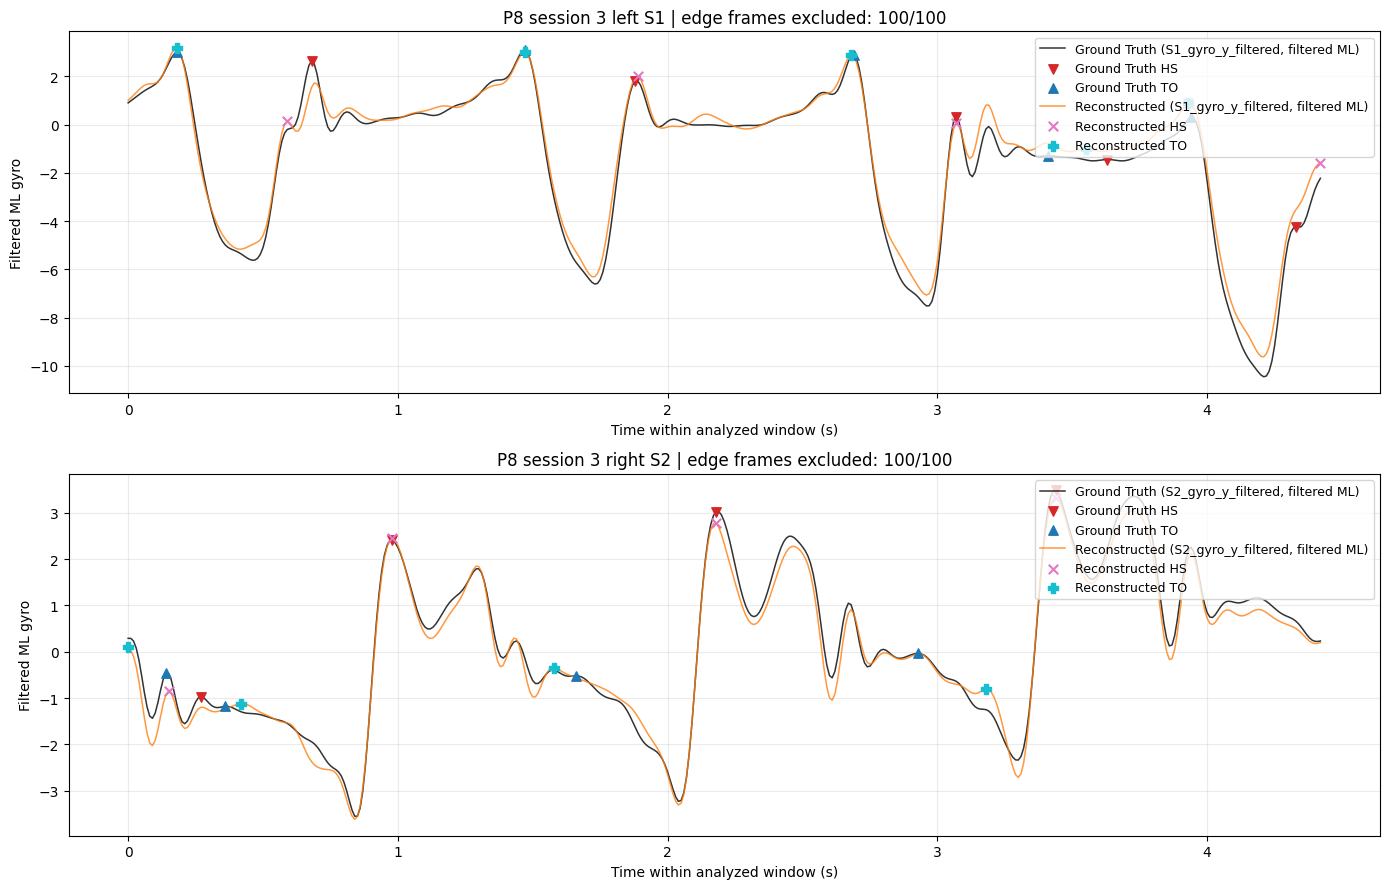

Saved example plot: /mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/outputs/P8/imu_real_virtual_val/cropped_first100_last100/figures/P8_3_gt_vs_reconstructed_events.png


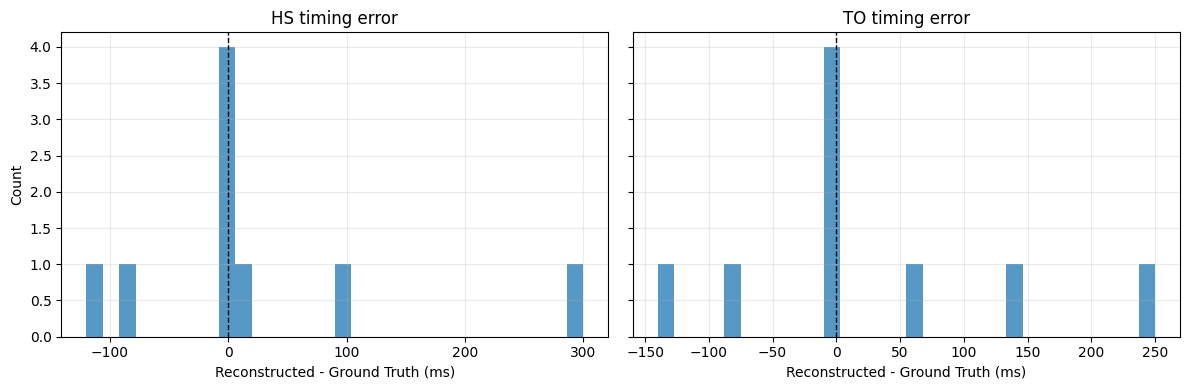

Saved histogram plot: /mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/outputs/P8/imu_real_virtual_val/cropped_first100_last100/figures/event_timing_error_histograms.png


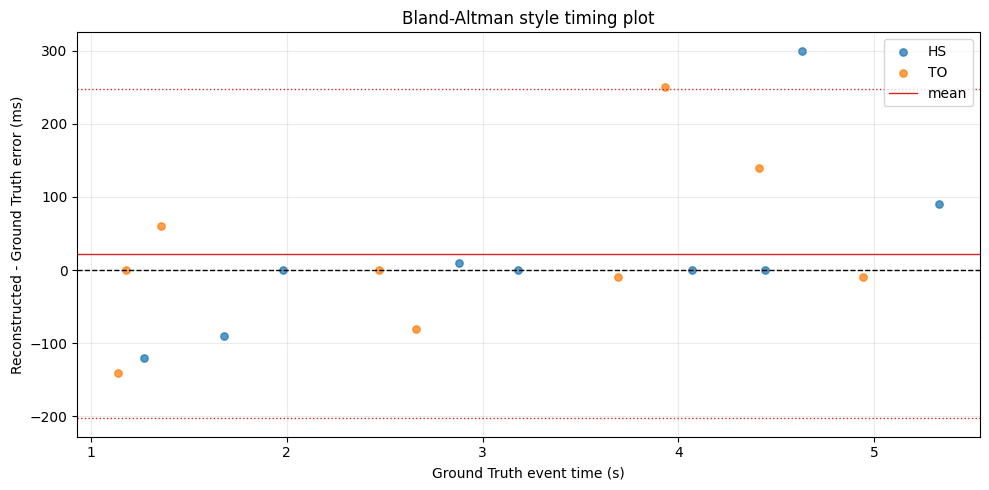

Saved Bland-Altman style plot: /mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/outputs/P8/imu_real_virtual_val/cropped_first100_last100/figures/bland_altman_style_event_timing.png


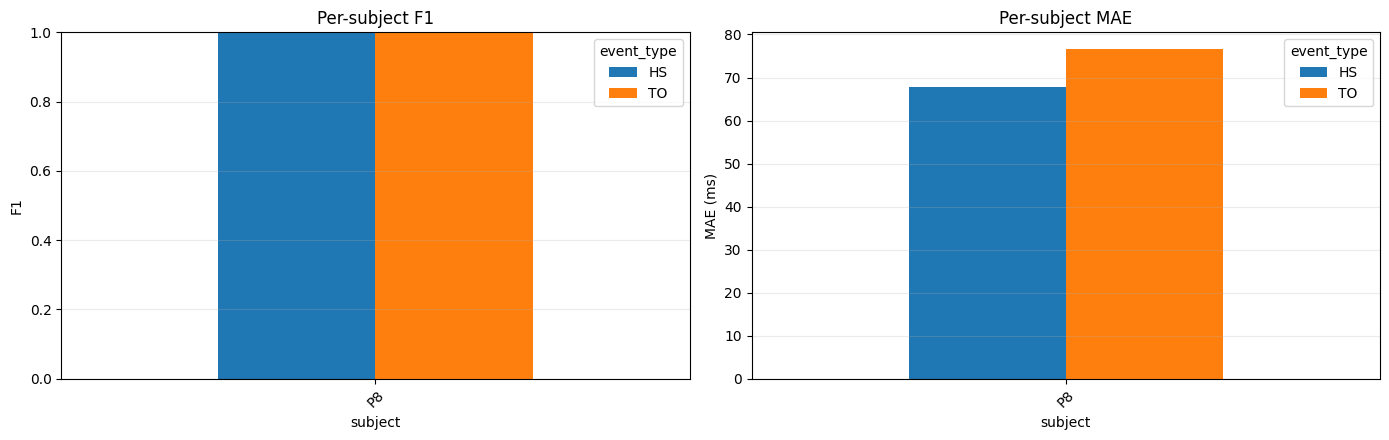

Saved per-subject plot: /mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/outputs/P8/imu_real_virtual_val/cropped_first100_last100/figures/per_subject_f1_mae.png


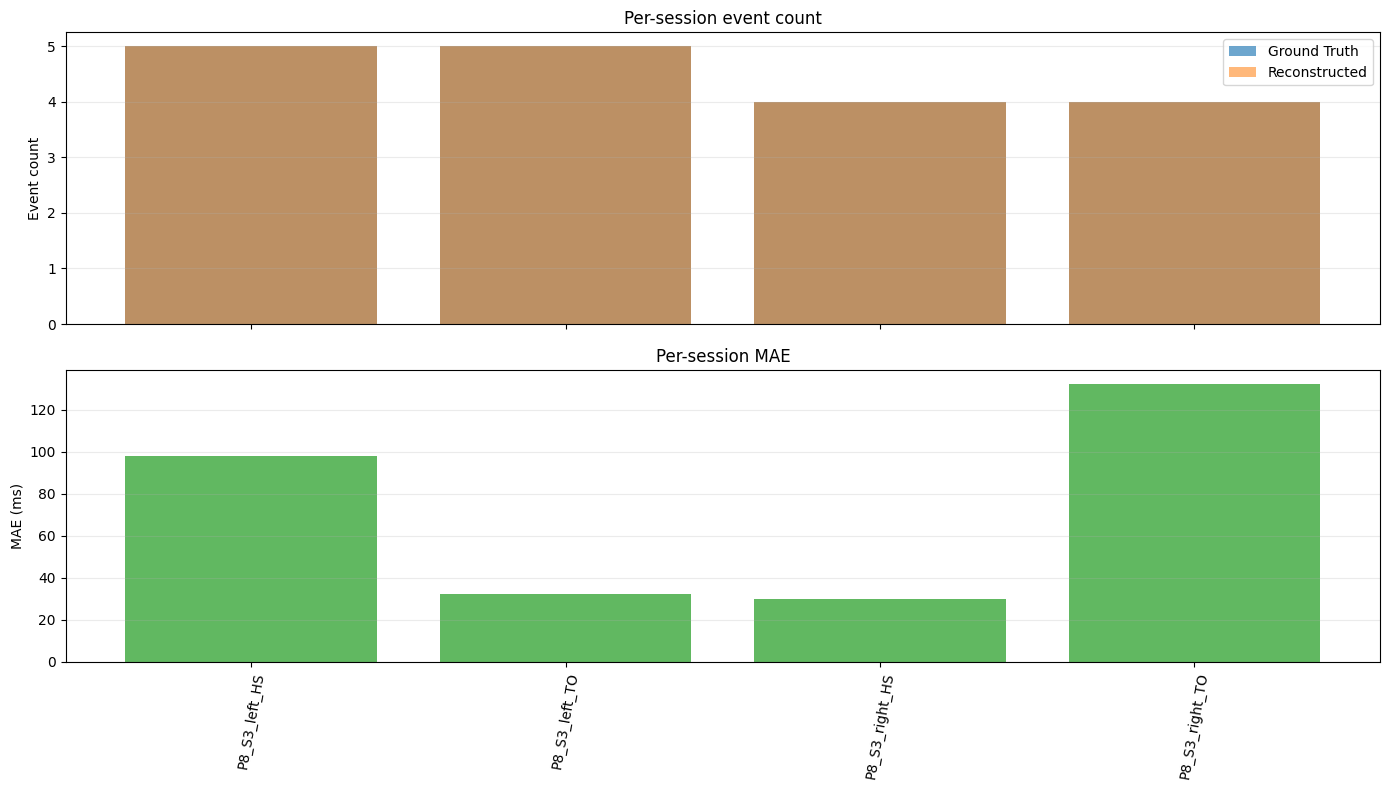

Saved per-session plot: /mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/outputs/P8/imu_real_virtual_val/cropped_first100_last100/figures/per_session_event_count_mae.png


PosixPath('/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/outputs/P8/imu_real_virtual_val/cropped_first100_last100/figures/per_session_event_count_mae.png')

In [10]:
def _plot_signal_for_sensor(ax, df, sensor_id, label, color, fs=None, side=None):
    """Plot the filtered medio-lateral gyro signal used by the paper detector."""
    fs = float(fs) if fs is not None and np.isfinite(fs) else infer_fs_from_data(df, CONFIG)
    selected, _, signal, _ = preprocess_mediolateral_gyro(df, sensor_id, fs, CONFIG, side=side)
    time_col = get_time_column(df)
    t = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float) if time_col else np.arange(len(df))
    if len(t) and np.isfinite(t[0]):
        t = t - t[0]
    ax.plot(t[:len(signal)], signal, color=color, linewidth=1.1, alpha=0.8, label=f"{label} ({selected}, filtered ML)")
    return t, signal


def plot_example_session(signal_cache, sessions_to_analyze, figure_dir=FIGURE_DIR):
    """Plot Ground Truth vs reconstructed signal and HS/TO markers for one session."""
    if not signal_cache:
        warnings.warn("No signal cache available for example plot.")
        return None
    subject = CONFIG["PLOT_EXAMPLE_SUBJECT"]
    session = CONFIG["PLOT_EXAMPLE_SESSION"]
    if subject is None or session is None:
        for s, sessions in sessions_to_analyze.items():
            if sessions:
                subject, session = s, sessions[0]
                break
    if subject is None:
        warnings.warn("No selected session available for plotting.")
        return None
    subject = normalize_subject_id(subject)
    session = canonical_session_id(session)

    sides = [side for side in CONFIG["SIDES_TO_USE"] if (subject, session, side, "ground_truth") in signal_cache]
    if not sides:
        warnings.warn(f"No plottable sides for {subject} session {session}.")
        return None

    trim_enabled, trim_first, trim_last = edge_frame_exclusion_settings(CONFIG)
    trim_label = f" | edge frames excluded: {trim_first}/{trim_last}" if trim_enabled and (trim_first or trim_last) else ""
    fig, axes = plt.subplots(len(sides), 1, figsize=(14, 4.5 * len(sides)), sharex=False)
    if len(sides) == 1:
        axes = [axes]
    for ax, side in zip(axes, sides):
        gt_item = signal_cache.get((subject, session, side, "ground_truth"))
        recon_item = signal_cache.get((subject, session, side, "reconstructed"))
        sensor_id = gt_item["sensor_id"]
        t_gt, y_gt = _plot_signal_for_sensor(ax, gt_item["df"], sensor_id, "Ground Truth", "black", fs=gt_item.get("fs"), side=side)
        for event_type, marker, color in [("HS", "v", "tab:red"), ("TO", "^", "tab:blue")]:
            idx = np.asarray(gt_item["events"].get(event_type, []), dtype=int)
            idx = idx[(idx >= 0) & (idx < len(y_gt))]
            if len(idx):
                ax.scatter(t_gt[idx], y_gt[idx], marker=marker, s=46, color=color, label=f"Ground Truth {event_type}", zorder=4)
        if recon_item is not None and not recon_item["df"].empty:
            t_recon, y_recon = _plot_signal_for_sensor(ax, recon_item["df"], sensor_id, "Reconstructed", "tab:orange", fs=recon_item.get("fs"), side=side)
            for event_type, marker, color in [("HS", "x", "tab:pink"), ("TO", "P", "tab:cyan")]:
                idx = np.asarray(recon_item["events"].get(event_type, []), dtype=int)
                idx = idx[(idx >= 0) & (idx < len(y_recon))]
                if len(idx):
                    ax.scatter(t_recon[idx], y_recon[idx], marker=marker, s=46, color=color, label=f"Reconstructed {event_type}", zorder=4)
        ax.set_title(f"{subject} session {session} {side} {sensor_id}{trim_label}")
        ax.set_xlabel("Time within analyzed window (s)" if trim_label else "Time within session (s)")
        ax.set_ylabel("Filtered ML gyro")
        ax.grid(True, alpha=0.25)
        ax.legend(loc="upper right", fontsize=9)
    fig.tight_layout()
    out = figure_dir / f"{safe_filename_part(subject)}_{safe_filename_part(session)}_gt_vs_reconstructed_events.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved example plot: {out}")
    return out


def plot_error_histograms(matched_df, figure_dir=FIGURE_DIR):
    """Plot HS and TO event timing error histograms."""
    if matched_df.empty:
        warnings.warn("No matched event details available for error histograms.")
        return None
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, event_type in zip(axes, ["HS", "TO"]):
        sub = matched_df[matched_df["event_type"] == event_type]
        if sub.empty:
            ax.set_title(f"{event_type}: no matches")
            continue
        ax.hist(sub["error_ms"], bins=30, alpha=0.75, color="tab:blue")
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"{event_type} timing error")
        ax.set_xlabel("Reconstructed - Ground Truth (ms)")
        ax.grid(True, alpha=0.25)
    axes[0].set_ylabel("Count")
    fig.tight_layout()
    out = figure_dir / "event_timing_error_histograms.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved histogram plot: {out}")
    return out


def plot_bland_altman_style(matched_df, figure_dir=FIGURE_DIR):
    """Plot Ground Truth event time versus reconstructed event timing error."""
    if matched_df.empty:
        warnings.warn("No matched event details available for Bland-Altman style plot.")
        return None
    fig, ax = plt.subplots(figsize=(10, 5))
    for event_type, g in matched_df.groupby("event_type"):
        ax.scatter(g["reference_time_sec"], g["error_ms"], s=28, alpha=0.75, label=event_type)
    mean_err = matched_df["error_ms"].mean()
    std_err = matched_df["error_ms"].std(ddof=1)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    if np.isfinite(mean_err):
        ax.axhline(mean_err, color="tab:red", linewidth=1, label="mean")
    if np.isfinite(std_err):
        ax.axhline(mean_err + 1.96 * std_err, color="tab:red", linestyle=":", linewidth=1)
        ax.axhline(mean_err - 1.96 * std_err, color="tab:red", linestyle=":", linewidth=1)
    ax.set_xlabel("Ground Truth event time (s)")
    ax.set_ylabel("Reconstructed - Ground Truth error (ms)")
    ax.set_title("Bland-Altman style timing plot")
    ax.grid(True, alpha=0.25)
    ax.legend()
    fig.tight_layout()
    out = figure_dir / "bland_altman_style_event_timing.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved Bland-Altman style plot: {out}")
    return out


def plot_per_subject_summary(summary_df, figure_dir=FIGURE_DIR):
    """Plot per-subject F1 and MAE for HS and TO."""
    if summary_df.empty:
        warnings.warn("No subject summary available for plotting.")
        return None
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    pivot_f1 = summary_df.pivot_table(index="subject", columns="event_type", values="f1")
    pivot_mae = summary_df.pivot_table(index="subject", columns="event_type", values="mae_ms")
    pivot_f1.plot(kind="bar", ax=axes[0])
    pivot_mae.plot(kind="bar", ax=axes[1])
    axes[0].set_title("Per-subject F1")
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel("F1")
    axes[1].set_title("Per-subject MAE")
    axes[1].set_ylabel("MAE (ms)")
    for ax in axes:
        ax.grid(True, axis="y", alpha=0.25)
        ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    out = figure_dir / "per_subject_f1_mae.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved per-subject plot: {out}")
    return out


def plot_per_session_summary(comparison_df, figure_dir=FIGURE_DIR):
    """Plot per-session event counts and MAE."""
    if comparison_df.empty:
        warnings.warn("No session comparison available for plotting.")
        return None
    plot_df = comparison_df.copy()
    plot_df["session_label"] = plot_df["subject"].astype(str) + "_S" + plot_df["session"].astype(str) + "_" + plot_df["side"].astype(str) + "_" + plot_df["event_type"].astype(str)
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    axes[0].bar(plot_df["session_label"], plot_df["number_ground_truth_events"], alpha=0.65, label="Ground Truth")
    axes[0].bar(plot_df["session_label"], plot_df["number_reconstructed_events"], alpha=0.55, label="Reconstructed")
    axes[0].set_ylabel("Event count")
    axes[0].set_title("Per-session event count")
    axes[0].legend()
    axes[1].bar(plot_df["session_label"], plot_df["mae_ms"], color="tab:green", alpha=0.75)
    axes[1].set_ylabel("MAE (ms)")
    axes[1].set_title("Per-session MAE")
    axes[1].tick_params(axis="x", rotation=80)
    for ax in axes:
        ax.grid(True, axis="y", alpha=0.25)
    fig.tight_layout()
    out = figure_dir / "per_session_event_count_mae.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved per-session plot: {out}")
    return out


plot_example_session(signal_cache, sessions_to_analyze)
plot_error_histograms(matched_event_details_df)
plot_bland_altman_style(matched_event_details_df)
plot_per_subject_summary(event_comparison_by_subject)
plot_per_session_summary(event_comparison_by_session)


## Save IMU Outputs


In [11]:
def save_csv(df, path):
    """Save a dataframe and print its shape."""
    df = df if df is not None else pd.DataFrame()
    df.to_csv(path, index=False)
    print(f"Saved {path.name}: shape={df.shape}")
    return path


save_csv(ground_truth_events_df, EVENT_DIR / "ground_truth_gait_events.csv")
save_csv(reconstructed_events_df, EVENT_DIR / "reconstructed_gait_events.csv")
save_csv(ground_truth_events_df, EVENT_DIR / "real_imu_gait_events.csv")
save_csv(reconstructed_events_df, EVENT_DIR / "virtual_imu_gait_events.csv")
save_csv(matched_event_details_df, EVENT_DIR / "matched_event_details.csv")
save_csv(event_comparison_by_session, SUMMARY_DIR / "event_comparison_by_session.csv")
save_csv(event_comparison_by_subject, SUMMARY_DIR / "event_comparison_by_subject.csv")
save_csv(event_comparison_by_side, SUMMARY_DIR / "event_comparison_by_side.csv")
save_csv(event_comparison_by_data_type, SUMMARY_DIR / "event_comparison_by_data_type.csv")
save_csv(event_comparison_overall, SUMMARY_DIR / "event_comparison_overall.csv")
save_csv(reconstruction_metadata_df, SUMMARY_DIR / "reconstruction_metadata.csv")
save_csv(detection_summary_df, SUMMARY_DIR / "detection_summary.csv")
save_csv(alignment_summary_df, SUMMARY_DIR / "alignment_summary.csv")

save_csv(skipped_sessions_df, SUMMARY_DIR / "skipped_sessions.csv")


def collect_imu_session_time_ranges(signal_cache):
    """Collect timestamp ranges for Real IMU and Virtual IMU session signals."""
    rows = []
    for (subject, session, side, source), item in signal_cache.items():
        if source not in {"real_imu", "virtual_imu"}:
            continue
        df = item.get("df", pd.DataFrame()).copy()
        if df.empty:
            continue
        if "imu_time_sec" in df.columns:
            times = pd.to_numeric(df["imu_time_sec"], errors="coerce")
        else:
            time_col = get_time_column(df)
            if time_col:
                times = pd.to_numeric(df[time_col], errors="coerce")
            else:
                fs = float(item.get("fs", CONFIG.get("FS") or 100.0))
                times = pd.Series(np.arange(len(df), dtype=float) / fs)
        finite = times[np.isfinite(times)]
        if finite.empty:
            continue
        rows.append({
            "subject": subject,
            "session": session,
            "side": side,
            "source": source,
            "sensor_id": item.get("sensor_id"),
            "data_type": item.get("data_type"),
            "imu_time_start_sec": float(finite.min()),
            "imu_time_end_sec": float(finite.max()),
            "n_samples": int(len(df)),
            "fs": float(item.get("fs", np.nan)),
        })
    return pd.DataFrame(rows)


imu_session_time_ranges_df = collect_imu_session_time_ranges(signal_cache)
save_csv(imu_session_time_ranges_df, SUMMARY_DIR / "imu_session_time_ranges.csv")


inference_metadata = {
    "active_subject": ACTIVE_SUBJECT,
    "selected_subjects": CONFIG.get("SELECTED_SUBJECTS"),
    "reconstruction_model_name": CONFIG.get("RECON_MODEL_NAME"),
    "model_notebook": str(MODEL_NOTEBOOK_PATH),
    "model_class": lstm_info.get("model_class"),
    "tcn_channels": lstm_info.get("tcn_channels"),
    "tcn_kernel_size": lstm_info.get("tcn_kernel_size"),
    "session_selection_mode": CONFIG.get("SESSIONS_TO_ANALYZE"),
    "model_train_sessions": lstm_info.get("train_sessions"),
    "model_validation_sessions": lstm_info.get("val_sessions"),
    "model_test_sessions": lstm_info.get("test_sessions"),
    "selected_sessions": sessions_to_analyze,
    "skipped_sessions": skipped_sessions_df.to_dict(orient="records"),
    "model_path": model_path_used,
    "scaler_path": scaler_path_used,
    "scaler_status": scaler_status,
    "input_sensors": lstm_info.get("input_sensors"),
    "target_sensors": lstm_info.get("target_sensors"),
    "input_cols": lstm_info.get("input_cols"),
    "target_cols": lstm_info.get("target_cols"),
    "event_sensors_configured": CONFIG.get("EVENT_SENSOR_MAP"),
    "event_sensors_effective": EFFECTIVE_EVENT_SENSOR_MAP,
    "event_sensor_warning": event_sensor_warning,
    "window_size": lstm_info.get("window_size"),
    "train_stride": lstm_info.get("train_stride"),
    "val_stride": lstm_info.get("val_stride"),
    "inference_stride": lstm_info.get("stride"),
    "sampling_frequency": CONFIG.get("FS") or "inferred_per_session",
    "output_dir": str(OUTPUT_DIR),
    "output_relative_dir": CONFIG.get("RESOLVED_OUTPUT_DIR"),
    "output_crop_status_label": CONFIG.get("OUTPUT_CROP_STATUS_LABEL"),
    "edge_frame_cropping_performed": bool(CONFIG.get("EXCLUDE_EDGE_FRAMES_FOR_ANALYSIS") and (CONFIG.get("EXCLUDE_FIRST_FRAMES", 0) or CONFIG.get("EXCLUDE_LAST_FRAMES", 0))),
    "edge_frame_exclusion_enabled": CONFIG.get("EXCLUDE_EDGE_FRAMES_FOR_ANALYSIS"),
    "excluded_first_frames": CONFIG.get("EXCLUDE_FIRST_FRAMES"),
    "excluded_last_frames": CONFIG.get("EXCLUDE_LAST_FRAMES"),
    "extra_filtering_applied": CONFIG.get("APPLY_EXTRA_FILTER"),
    "extra_filter_cutoff": CONFIG.get("EXTRA_FILTER_CUTOFF") if CONFIG.get("APPLY_EXTRA_FILTER") else None,
    "extra_filter_order": CONFIG.get("EXTRA_FILTER_ORDER") if CONFIG.get("APPLY_EXTRA_FILTER") else None,
    "event_detection_method": CONFIG.get("EVENT_DETECTION_METHOD"),
    "event_matching_tolerance_sec": CONFIG.get("EVENT_MATCH_TOLERANCE_SEC"),
    "romijnders_reference": "Romijnders et al. 2021, J NeuroEngineering Rehabil 18:28, doi:10.1186/s12984-021-00828-0",
    "mediolateral_gyro_axis": CONFIG.get("MEDIOLATERAL_GYRO_AXIS"),
    "mediolateral_gyro_sign": CONFIG.get("MEDIOLATERAL_GYRO_SIGN"),
    "romijnders_highpass_cutoff": CONFIG.get("ROMIJNDERS_HIGHPASS_CUTOFF"),
    "romijnders_highpass_order": CONFIG.get("ROMIJNDERS_HIGHPASS_ORDER"),
    "romijnders_lowpass_cutoff": CONFIG.get("ROMIJNDERS_LOWPASS_CUTOFF"),
    "romijnders_lowpass_order": CONFIG.get("ROMIJNDERS_LOWPASS_ORDER"),
    "romijnders_midswing_threshold_fraction": CONFIG.get("ROMIJNDERS_MIDSWING_THRESHOLD_FRACTION"),
    "romijnders_expected_gait_cycle_sec": CONFIG.get("ROMIJNDERS_EXPECTED_GAIT_CYCLE_SEC"),
    "romijnders_min_midswing_interval_sec": CONFIG.get("ROMIJNDERS_MIN_MIDSWING_INTERVAL_SEC"),
    "romijnders_peak_merge_window_sec": CONFIG.get("ROMIJNDERS_PEAK_MERGE_WINDOW_SEC"),
    "paper_event_mapping": "IC->HS, FC->TO",
}
with open(SUMMARY_DIR / "inference_metadata.json", "w", encoding="utf-8") as f:
    json.dump(inference_metadata, f, indent=2)
print(f"Saved inference metadata: {SUMMARY_DIR / 'inference_metadata.json'}")


Saved ground_truth_gait_events.csv: shape=(27, 13)
Saved reconstructed_gait_events.csv: shape=(27, 13)
Saved real_imu_gait_events.csv: shape=(27, 13)
Saved virtual_imu_gait_events.csv: shape=(27, 13)
Saved matched_event_details.csv: shape=(18, 13)
Saved event_comparison_by_session.csv: shape=(4, 21)
Saved event_comparison_by_subject.csv: shape=(2, 15)
Saved event_comparison_by_side.csv: shape=(4, 15)
Saved event_comparison_by_data_type.csv: shape=(2, 15)
Saved event_comparison_overall.csv: shape=(2, 14)
Saved reconstruction_metadata.csv: shape=(1, 10)
Saved detection_summary.csv: shape=(4, 27)
Saved alignment_summary.csv: shape=(1, 16)
Saved skipped_sessions.csv: shape=(0, 3)
Saved imu_session_time_ranges.csv: shape=(4, 10)
Saved inference metadata: /mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/outputs/P8/imu_real_virtual_val/cropped_first100_last100/summaries/inference_metadata.json


## Summary


In [12]:
def _metric_text(summary_df, event_type):
    """Format overall event metrics."""
    if summary_df.empty or "event_type" not in summary_df.columns:
        return "not available"
    row = summary_df[summary_df["event_type"] == event_type]
    if row.empty:
        return "not available"
    row = row.iloc[0]
    f1 = row.get("f1", np.nan)
    mae = row.get("mae_ms", np.nan)
    return f"F1={f1:.3f}, MAE={mae:.1f} ms" if np.isfinite(f1) or np.isfinite(mae) else "not available"


print("\n=== IMU Gait Event Summary ===")
print("Analyzed subjects and sessions:")
print(json.dumps(sessions_to_analyze, indent=2))
print(f"Number of Real IMU-derived events: {len(ground_truth_events_df)}")
print(f"Number of Virtual/Reconstructed IMU events: {len(reconstructed_events_df)}")
print(f"Real-vs-Virtual consistency HS: {_metric_text(event_comparison_overall, 'HS')}")
print(f"Real-vs-Virtual consistency TO: {_metric_text(event_comparison_overall, 'TO')}")
print("\nLeft/right summary:")
display(event_comparison_by_side)
print("\nIMU session time ranges:")
display(imu_session_time_ranges_df)
print(
    "Romijnders detector: "
    f"ML gyro axis={CONFIG['MEDIOLATERAL_GYRO_AXIS']}, "
    f"HP={CONFIG['ROMIJNDERS_HIGHPASS_CUTOFF']} Hz, "
    f"LP={CONFIG['ROMIJNDERS_LOWPASS_CUTOFF']} Hz, "
    f"mid-swing threshold={CONFIG['ROMIJNDERS_MIDSWING_THRESHOLD_FRACTION']} * global minimum, "
    f"min mid-swing interval={CONFIG['ROMIJNDERS_MIN_MIDSWING_INTERVAL_SEC']} s."
)
print(
    "Edge-frame exclusion: "
    f"enabled={CONFIG['EXCLUDE_EDGE_FRAMES_FOR_ANALYSIS']}, "
    f"first={CONFIG['EXCLUDE_FIRST_FRAMES']} frames, "
    f"last={CONFIG['EXCLUDE_LAST_FRAMES']} frames."
)
print("Paper event mapping in saved CSVs: IC->HS, FC->TO.")



=== IMU Gait Event Summary ===
Analyzed subjects and sessions:
{
  "P8": [
    "3"
  ]
}
Number of Real IMU-derived events: 27
Number of Virtual/Reconstructed IMU events: 27
Real-vs-Virtual consistency HS: F1=1.000, MAE=67.8 ms
Real-vs-Virtual consistency TO: F1=1.000, MAE=76.7 ms

Left/right summary:


,side,event_type,TP,FP,FN,precision,recall,f1,mae_ms,bias_ms,std_ms,iqr_ms,number_ground_truth_events,number_reconstructed_events,number_matched_events
0,left,HS,5,0,0,1.0,1.0,1.0,98.0,62.0,147.546603,90.0,5,5,5
1,left,TO,5,0,0,1.0,1.0,1.0,32.0,24.0,65.038450,10.0,5,5,5
2,right,HS,4,0,0,1.0,1.0,1.0,30.0,-30.0,60.000000,30.0,4,4,4
3,right,TO,4,0,0,1.0,1.0,1.0,132.5,22.5,173.277235,202.5,4,4,4



IMU session time ranges:


,subject,session,side,source,sensor_id,data_type,imu_time_start_sec,imu_time_end_sec,n_samples,fs
0,P8,3,left,real_imu,S1,withoutcane,311.62,316.04,443,100.0
1,P8,3,left,virtual_imu,S1,withoutcane,311.62,316.04,443,100.0
2,P8,3,right,real_imu,S2,withoutcane,311.62,316.04,443,100.0
3,P8,3,right,virtual_imu,S2,withoutcane,311.62,316.04,443,100.0


Romijnders detector: ML gyro axis=y, HP=0.15 Hz, LP=10.0 Hz, mid-swing threshold=0.1 * global minimum, min mid-swing interval=0.6 s.
Edge-frame exclusion: enabled=True, first=100 frames, last=100 frames.
Paper event mapping in saved CSVs: IC->HS, FC->TO.
